In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle 
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

## Funciones

In [21]:
import numpy as np
import pandas as pd

def aplicar_transformaciones(df, stats=None, es_train=True):
    df = df.copy()

    # Meses anteriores a 3 (en tu dataset: 4, 5, 6)
    pay_cols = [f'PAY_{i}' for i in range(4, 7)]
    pay_amt_cols = [f'PAY_AMT{i}' for i in range(4, 7)]
    bill_amt_cols = [f'BILL_AMT{i}' for i in range(4, 7)]

    # Variables agregadas sin usar el mes objetivo
    df['Ratio_Debt'] = df[bill_amt_cols].sum(axis=1) / df['LIMIT_BAL']
    df['Max_Estatus_Pay'] = df[pay_cols].max(axis=1)
    df['Promedio_Estatus_Pay'] = df[pay_cols].mean(axis=1)
    df['Ratio_Payment'] = df[pay_amt_cols].sum(axis=1) / df['LIMIT_BAL']
    df['Count_Pay_Retrasados'] = (df[pay_cols] > 0).sum(axis=1)
    df['Count_Pay_A_Tiempo'] = (df[pay_cols] == -1).sum(axis=1)
    df['Total_Pay'] = df[pay_amt_cols].sum(axis=1)
    df['Total_Bill'] = df[bill_amt_cols].sum(axis=1)
    df['Pay/Bill'] = np.where(df['Total_Bill'] == 0, 0, df['Total_Pay'] / df['Total_Bill'])

    # Tendencias (solo meses 4 a 6)
    df['Pay_tendencia'] = df['PAY_AMT4'] - df['PAY_AMT6']
    df['Bill_tendencia'] = df['BILL_AMT4'] - df['BILL_AMT6']
    df['Diff_Bill_Pay'] = df['Total_Bill'] - df['Total_Pay']
    df['Diff_Bill_Pay_Tendencia'] = (df['BILL_AMT4'] - df['PAY_AMT4']) - (df['BILL_AMT6'] - df['PAY_AMT6'])

    # Conteos de pagos completos y deudas
    df['Meses_Pago_Completo'] = sum([
        (df[f'PAY_AMT{i}'] >= df[f'BILL_AMT{i}']).astype(int)
        for i in range(4, 7)
    ])
    df['Meses_Deuda'] = sum([
        (df[f'PAY_AMT{i}'] <= df[f'BILL_AMT{i}']).astype(int)
        for i in range(4, 7)
    ])

    # Inicializar stats
    if stats is None:
        stats = {}

    if es_train:
        stats['pay_std'] = df[pay_amt_cols].std(axis=1).mean()
        stats['pay_mean'] = df[pay_amt_cols].mean(axis=1).mean()
        stats['bill_mean'] = df[bill_amt_cols].mean(axis=1).mean()

        _, bins_age = pd.qcut(df['AGE'], q=4, retbins=True, duplicates='drop')
        stats['age_bins'] = bins_age
        stats['age_labels'] = ['Joven', 'Adulto joven', 'Adulto', 'Mayor']
    else:
        for key in ['pay_std', 'pay_mean', 'bill_mean', 'age_bins', 'age_labels']:
            if key not in stats:
                raise ValueError(f"'{key}' no está en stats para predicción.")

    df['Age_Quartile'] = pd.cut(df['AGE'], bins=stats['age_bins'], labels=stats['age_labels'], include_lowest=True, right=True).astype(str)
    df['Age_Quartile'] = df['Age_Quartile'].fillna('Desconocido')

    df['Pago_desviacion'] = df[pay_amt_cols].std(axis=1).fillna(stats['pay_std'])
    df['Pay_amount_mean'] = df[pay_amt_cols].mean(axis=1).fillna(stats['pay_mean'])
    df['Bill_amount_mean'] = df[bill_amt_cols].mean(axis=1).fillna(stats['bill_mean'])

    # Tendencia amplia
    df['Pay_tendencia_Amplia'] = df[pay_amt_cols[:2]].mean(axis=1) - df[pay_amt_cols[2:]].mean(axis=1)
    df['Bill_tendencia_Amplia'] = df[bill_amt_cols[:2]].mean(axis=1) - df[bill_amt_cols[2:]].mean(axis=1)

    df['Diff_Bill_Pay_Tendencia_Amplia'] = (
        df[bill_amt_cols[:2]].mean(axis=1) - df[pay_amt_cols[:2]].mean(axis=1) -
        (df[bill_amt_cols[2:]].mean(axis=1) - df[pay_amt_cols[2:]].mean(axis=1))
    )

    # Tendencia ponderada
    pesos = [1, 0.75, 0.6]
    df['Pay_tendencia_ponderada'] = sum([
        df[f'PAY_AMT{i}'] * peso for i, peso in zip(range(4, 7), pesos)
    ])
    pesos_bills = [1, 0.75, 0.6]
    df['Bill_tendencia_ponderada'] = sum([
        df[f'BILL_AMT{i}'] * peso for i, peso in zip(range(4, 7), pesos_bills)
    ])

    return (df, stats) if es_train else df


## Analisis de Datos

### Lectura de Datos

In [22]:
seed = 666
np.random.seed(seed)

In [23]:
df = pd.read_csv('datos/train_PAY_AMT3.csv', sep = '|' )

In [24]:
pd.set_option('display.max_columns',None)
df

,CUSTOMER_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,2662,180000.0,1,2,2,27,-1,-1,-1,644.0,29944.0,644.0,264.0,29944.0,644.0,264.0,1024.0
1,12809,50000.0,1,1,3,45,0,0,0,14388.0,18804.0,23460.0,27870.0,5000.0,5000.0,5000.0,5000.0
2,25951,250000.0,1,2,1,36,0,0,0,157088.0,136787.0,139385.0,122947.0,5200.0,5500.0,5000.0,5000.0
3,9209,280000.0,1,1,1,31,-2,-2,-2,1345.0,-5.0,-5.0,985.0,0.0,0.0,990.0,3090.0
4,5954,50000.0,2,2,3,42,0,0,0,50694.0,44858.0,19298.0,19514.0,1572.0,5000.0,1000.0,813.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,23545,20000.0,1,2,1,48,-2,-2,-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5621,15967,20000.0,1,2,2,42,0,2,0,11714.0,13923.0,13405.0,13683.0,2726.0,0.0,643.0,646.0
5622,5993,170000.0,2,1,2,31,-1,-1,-1,7315.0,10730.0,1686.0,9445.0,10730.0,1686.0,9445.0,3444.0
5623,1515,100000.0,2,1,2,29,2,2,2,67564.0,67443.0,65106.0,70258.0,2500.0,0.0,6918.0,3520.0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5625 entries, 0 to 5624
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CUSTOMER_ID  5625 non-null   int64  
 1   LIMIT_BAL    5625 non-null   float64
 2   SEX          5625 non-null   int64  
 3   EDUCATION    5625 non-null   int64  
 4   MARRIAGE     5625 non-null   int64  
 5   AGE          5625 non-null   int64  
 6   PAY_4        5625 non-null   int64  
 7   PAY_5        5625 non-null   int64  
 8   PAY_6        5625 non-null   int64  
 9   BILL_AMT3    5625 non-null   float64
 10  BILL_AMT4    5625 non-null   float64
 11  BILL_AMT5    5625 non-null   float64
 12  BILL_AMT6    5625 non-null   float64
 13  PAY_AMT3     5625 non-null   float64
 14  PAY_AMT4     5625 non-null   float64
 15  PAY_AMT5     5625 non-null   float64
 16  PAY_AMT6     5625 non-null   float64
dtypes: float64(9), int64(8)
memory usage: 747.2 KB


In [26]:
df.describe([0.01,0.05, 0.25, 0.5, 0.75, 0.95 ,0.99])

,CUSTOMER_ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000
mean,14792.455289,167642.666667,1.588622,1.854222,1.542222,35.575111,-0.213689,-0.269156,-0.284444,46071.042311,42955.276622,39541.561422,37884.078044,5304.644800,4672.380089,4534.108978,5407.481778
std,8628.206383,130331.221117,0.492127,0.797005,0.523322,9.213164,1.208607,1.157610,1.180153,67924.291719,64142.022806,59848.537614,58307.728327,17493.393385,15377.027533,14408.222644,18516.746575
min,10.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-157264.000000,-15000.000000,-37594.000000,-73895.000000,0.000000,0.000000,0.000000,0.000000
1%,324.720000,10000.000000,1.000000,1.000000,1.000000,22.000000,-2.000000,-2.000000,-2.000000,-238.320000,-232.040000,-200.000000,-340.560000,0.000000,0.000000,0.000000,0.000000
5%,1554.200000,20000.000000,1.000000,1.000000,1.000000,24.000000,-2.000000,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7222.000000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,2417.000000,2270.000000,1727.000000,1047.000000,350.000000,257.000000,150.000000,76.000000
50%,14742.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,19690.000000,18864.000000,17515.000000,16062.000000,1800.000000,1500.000000,1452.000000,1445.000000
75%,22196.000000,240000.000000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,59024.000000,53682.000000,49264.000000,47869.000000,4584.000000,4000.000000,4000.000000,4000.000000
95%,28469.600000,440000.000000,2.000000,3.000000,2.000000,53.000000,2.000000,2.000000,2.000000,186863.600000,175232.400000,166705.200000,161687.000000,17990.800000,15727.800000,15439.800000,18979.000000


In [27]:
df.isnull().sum()

CUSTOMER_ID    0
LIMIT_BAL      0
SEX            0
EDUCATION      0
MARRIAGE       0
AGE            0
PAY_4          0
PAY_5          0
PAY_6          0
BILL_AMT3      0
BILL_AMT4      0
BILL_AMT5      0
BILL_AMT6      0
PAY_AMT3       0
PAY_AMT4       0
PAY_AMT5       0
PAY_AMT6       0
dtype: int64

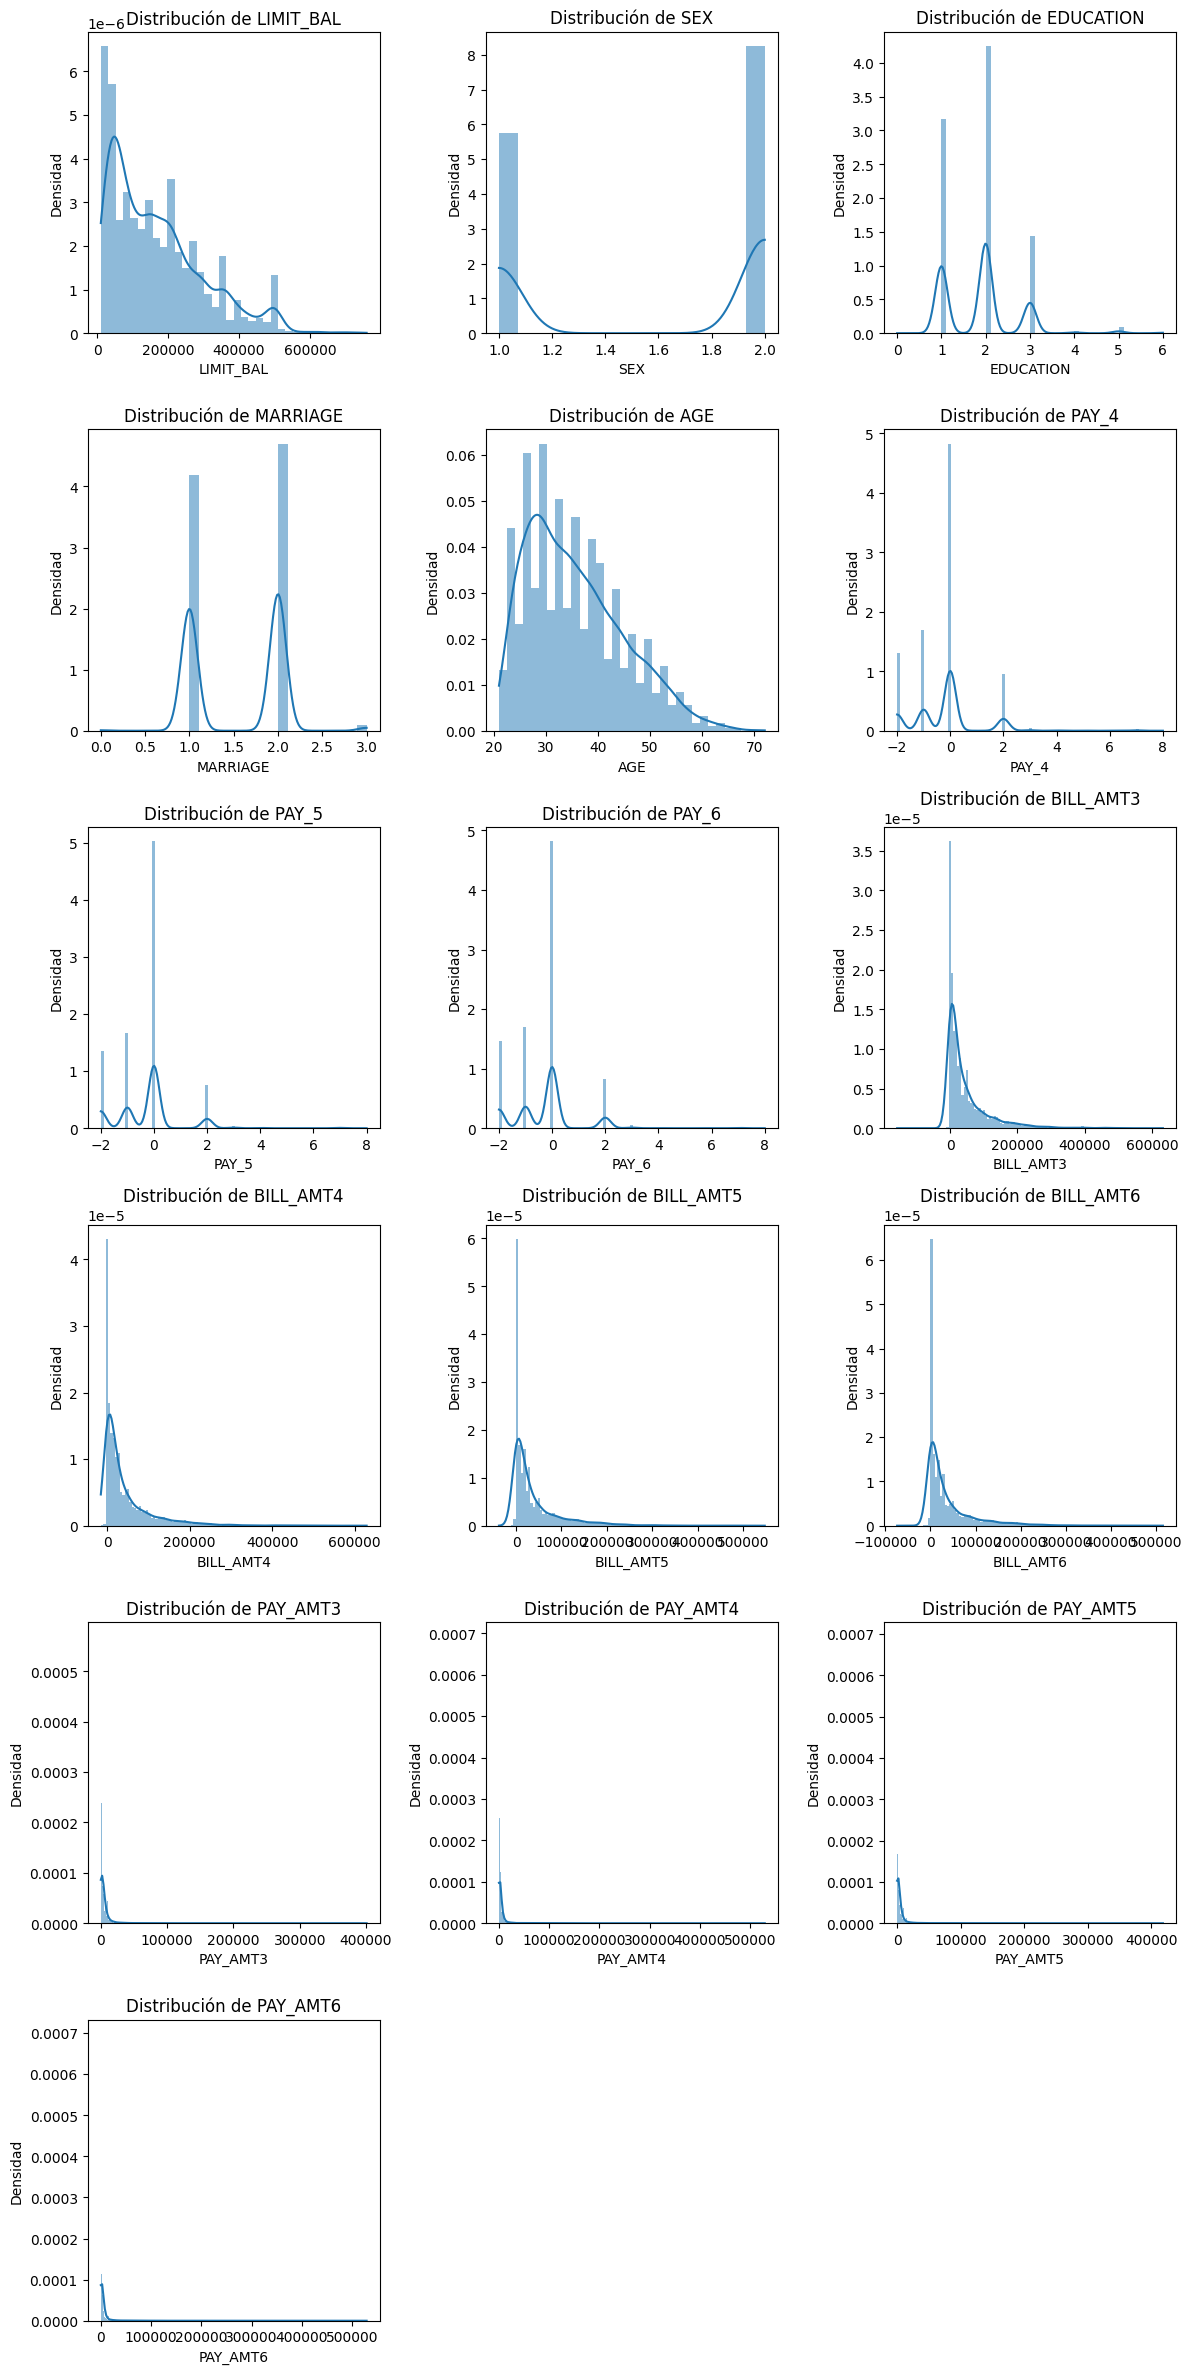

In [28]:
aux = df.drop(columns = 'CUSTOMER_ID')
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

## Ingenieria de variables

In [29]:
X_train, X_test , y_train, y_test = train_test_split(df.drop(columns=['CUSTOMER_ID','PAY_AMT3']), 
                                                     df['PAY_AMT3'], train_size=0.7, random_state=seed)

In [30]:
df = X_train.copy()

In [31]:
df, stats = aplicar_transformaciones(df, stats=None,es_train=True)

In [32]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada
1779,110000.0,1,2,1,39,0,0,0,34533.0,36819.0,32467.0,35806.0,3000.0,4000.0,3000.0,0.955382,0,0.000000,0.090909,0,0,10000.0,105092.0,0.095155,0.0,1013.0,95092.0,1013.0,0,3,Adulto,577.350269,3333.333333,35030.666667,500.0,-1163.0,-1663.0,7800.00,82652.85
1070,130000.0,1,2,2,25,0,0,0,7559.0,5198.0,5198.0,5198.0,0.0,0.0,0.0,0.119954,0,0.000000,0.000000,0,0,0.0,15594.0,0.000000,0.0,0.0,15594.0,0.0,0,3,Joven,0.000000,0.000000,5198.000000,0.0,0.0,0.0,0.00,12215.30
3385,50000.0,1,3,1,41,2,0,0,29261.0,28444.0,28878.0,27655.0,1100.0,1100.0,2000.0,1.699540,2,0.666667,0.084000,1,0,4200.0,84977.0,0.049425,-900.0,789.0,80777.0,1689.0,0,3,Adulto,519.615242,1400.000000,28325.666667,-900.0,1006.0,1906.0,3125.00,66695.50
2705,70000.0,2,2,1,41,3,3,2,53896.0,54426.0,52956.0,54459.0,0.0,2500.0,2200.0,2.312014,3,2.666667,0.067143,3,0,4700.0,161841.0,0.029041,-2200.0,-33.0,157141.0,2167.0,0,3,Adulto,1365.039682,1566.666667,53947.000000,-950.0,-768.0,182.0,3195.00,126818.40
4025,400000.0,2,1,2,31,-1,0,0,28082.0,20188.0,68992.0,27613.0,57060.0,16017.0,115710.0,0.291982,0,-0.333333,0.471967,0,1,188787.0,116793.0,1.616424,-58650.0,-7425.0,-71994.0,51225.0,2,1,Adulto joven,50104.964155,62929.000000,38931.000000,-79171.5,16977.0,96148.5,138498.75,88499.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,120000.0,1,2,2,25,2,2,0,54675.0,52206.0,10325.0,8992.0,0.0,500.0,1000.0,0.596025,2,1.333333,0.012500,2,0,1500.0,71523.0,0.020972,-1000.0,43214.0,70023.0,44214.0,0,3,Joven,500.000000,500.000000,23841.000000,-750.0,22273.5,23023.5,975.00,65344.95
70,140000.0,2,1,2,27,0,0,0,29840.0,31349.0,35687.0,36983.0,5000.0,2000.0,5000.0,0.742993,0,0.000000,0.085714,0,0,12000.0,104019.0,0.115364,0.0,-5634.0,92019.0,-5634.0,0,3,Joven,1732.050808,4000.000000,34673.000000,-1500.0,-3465.0,-1965.0,9500.00,80304.05
2878,160000.0,1,1,2,27,-1,-1,-1,5958.0,55914.0,23285.0,29170.0,23302.0,11580.0,9976.0,0.677306,-1,-1.000000,0.280363,0,3,44858.0,108369.0,0.413938,13326.0,26744.0,63511.0,13418.0,0,3,Joven,7275.075899,14952.666667,36123.000000,7465.0,10429.5,2964.5,37972.60,90879.75
1950,80000.0,2,2,1,49,0,0,0,47941.0,47851.0,48804.0,50033.0,1732.0,2000.0,3003.0,1.833600,0,0.000000,0.084187,0,0,6735.0,146688.0,0.045914,-1271.0,-2182.0,139953.0,-911.0,0,3,Mayor,669.984328,2245.000000,48896.000000,-1137.0,-1705.5,-568.5,5033.80,114473.80


In [33]:
X_test = aplicar_transformaciones(X_test, stats=stats, es_train=False)

In [34]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada
3782,150000.0,2,1,1,54,-2,-2,-2,329.0,39919.0,263.0,263.0,264.0,264.0,790.0,0.269633,-2,-2.000000,0.008787,0,0,1318.0,40445.0,0.032587,-526.0,39656.0,39127.0,40182.0,2,1,Mayor,303.686242,439.333333,13481.666667,-526.0,19828.0,20354.0,936.0,40274.05
4889,10000.0,2,2,1,37,0,2,0,8226.0,9834.0,9549.0,9774.0,0.0,508.0,425.0,2.915700,2,0.666667,0.093300,1,0,933.0,29157.0,0.031999,-425.0,60.0,28224.0,485.0,0,3,Adulto,272.512385,311.000000,9719.000000,-171.0,-82.5,88.5,636.0,22860.15
1302,70000.0,2,1,1,23,-2,-2,-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-2,-2.000000,0.000000,0,0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,3,3,Joven,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
313,10000.0,1,2,2,25,0,0,0,7308.0,5736.0,6236.0,-764.0,500.0,180.0,5000.0,1.120800,0,0.000000,0.568000,0,0,5680.0,11208.0,0.506781,-4500.0,6500.0,5528.0,11000.0,1,2,Joven,2695.205620,1893.333333,3736.000000,-4660.0,6750.0,11410.0,3635.0,9954.60
5138,20000.0,1,2,1,34,0,0,0,19499.0,19780.0,780.0,0.0,0.0,0.0,0.0,1.028000,0,0.000000,0.000000,0,0,0.0,20560.0,0.000000,0.0,19780.0,20560.0,19780.0,1,3,Adulto joven,0.000000,0.000000,6853.333333,0.0,10280.0,10280.0,0.0,20365.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,20000.0,1,3,2,27,0,0,0,19872.0,20100.0,19704.0,18004.0,394.0,0.0,226.0,2.890400,0,0.000000,0.031000,0,0,620.0,57808.0,0.010725,168.0,2096.0,57188.0,1928.0,0,3,Joven,197.710226,206.666667,19269.333333,-29.0,1898.0,1927.0,529.6,45680.40
2379,260000.0,2,1,1,52,2,-1,-1,150.0,150.0,2500.0,0.0,2500.0,0.0,0.0,0.010192,2,0.000000,0.009615,1,2,2500.0,2650.0,0.943396,2500.0,150.0,150.0,-2350.0,2,2,Mayor,1443.375673,833.333333,883.333333,1250.0,1325.0,75.0,2500.0,2025.00
2271,50000.0,2,1,2,25,0,2,2,36989.0,38559.0,39958.0,38313.0,3000.0,0.0,3090.0,2.336600,2,1.333333,0.121800,2,0,6090.0,116830.0,0.052127,-90.0,246.0,110740.0,336.0,0,3,Joven,1758.607404,2030.000000,38943.333333,-1590.0,945.5,2535.5,4854.0,91515.30
5140,10000.0,1,2,2,24,0,0,0,4810.0,7546.0,9260.0,10000.0,2000.0,1000.0,0.0,2.680600,0,0.000000,0.300000,0,0,3000.0,26806.0,0.111915,2000.0,-2454.0,23806.0,-4454.0,0,3,Joven,1000.000000,1000.000000,8935.333333,1500.0,-1597.0,-3097.0,2750.0,20491.00


In [35]:
X_test.isnull().sum().sum()

np.int64(0)

In [36]:
df.isna().sum().sum()

np.int64(0)

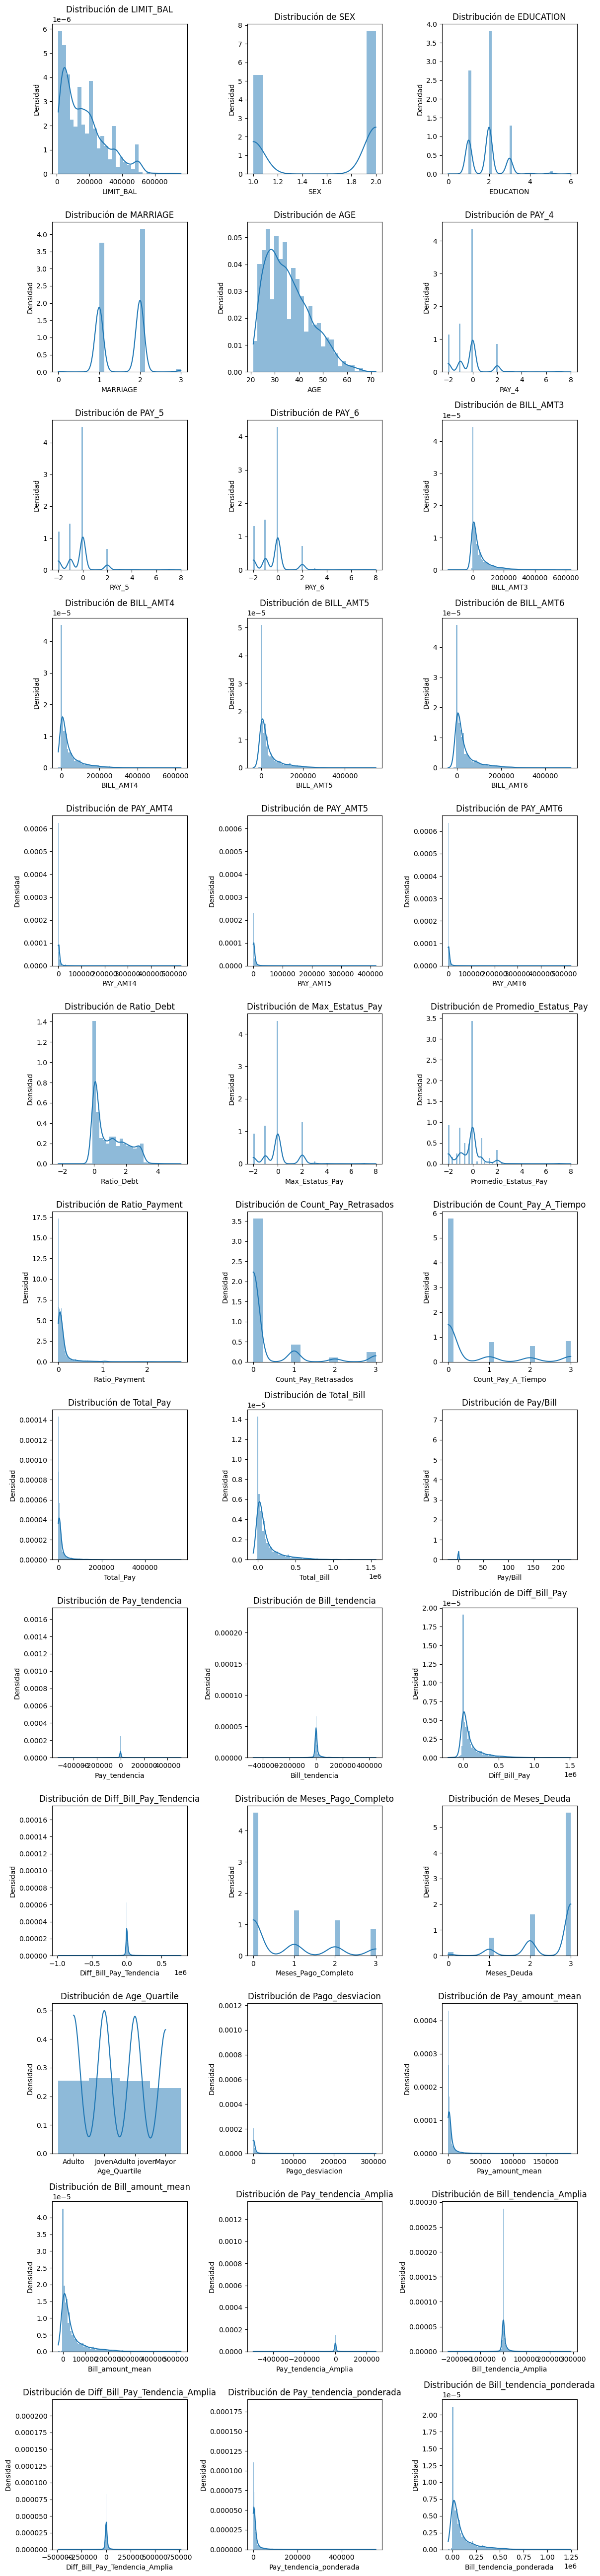

In [37]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

In [45]:
lst_column_log = ['LIMIT_BAL','AGE','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
                  'PAY_AMT4','PAY_AMT5','PAY_AMT6','Ratio_Debt','Ratio_Payment','Total_Pay','Total_Bill',
                  'Pay_amount_mean','Bill_amount_mean','Diff_Bill_Pay','Pay_tendencia_ponderada','Bill_tendencia_ponderada','Pago_desviacion']

In [46]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT4',
       'PAY_AMT5', 'PAY_AMT6', 'Ratio_Debt', 'Max_Estatus_Pay',
       'Promedio_Estatus_Pay', 'Ratio_Payment', 'Count_Pay_Retrasados',
       'Count_Pay_A_Tiempo', 'Total_Pay', 'Total_Bill', 'Pay/Bill',
       'Pay_tendencia', 'Bill_tendencia', 'Diff_Bill_Pay',
       'Diff_Bill_Pay_Tendencia', 'Meses_Pago_Completo', 'Meses_Deuda',
       'Age_Quartile', 'Pago_desviacion', 'Pay_amount_mean',
       'Bill_amount_mean', 'Pay_tendencia_Amplia', 'Bill_tendencia_Amplia',
       'Diff_Bill_Pay_Tendencia_Amplia', 'Pay_tendencia_ponderada',
       'Bill_tendencia_ponderada', 'LIMIT_BAL_log', 'AGE_log', 'BILL_AMT3_log',
       'BILL_AMT4_log', 'BILL_AMT5_log', 'BILL_AMT6_log'],
      dtype='object')

In [47]:
lst_column_log

['LIMIT_BAL',
 'AGE',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'Ratio_Debt',
 'Ratio_Payment',
 'Total_Pay',
 'Total_Bill',
 'Pay_amount_mean',
 'Bill_amount_mean',
 'Diff_Bill_Pay',
 'Pay_tendencia_ponderada',
 'Bill_tendencia_ponderada',
 'Pago_desviacion']

In [48]:
for col in lst_column_log:
    offset = abs(df[col].min()) + 1
    df[f'{col}_log'] = np.log1p(np.maximum(df[col] + offset,0))
    X_test[f'{col}_log'] = np.log1p(np.maximum(X_test[col] + offset,0))

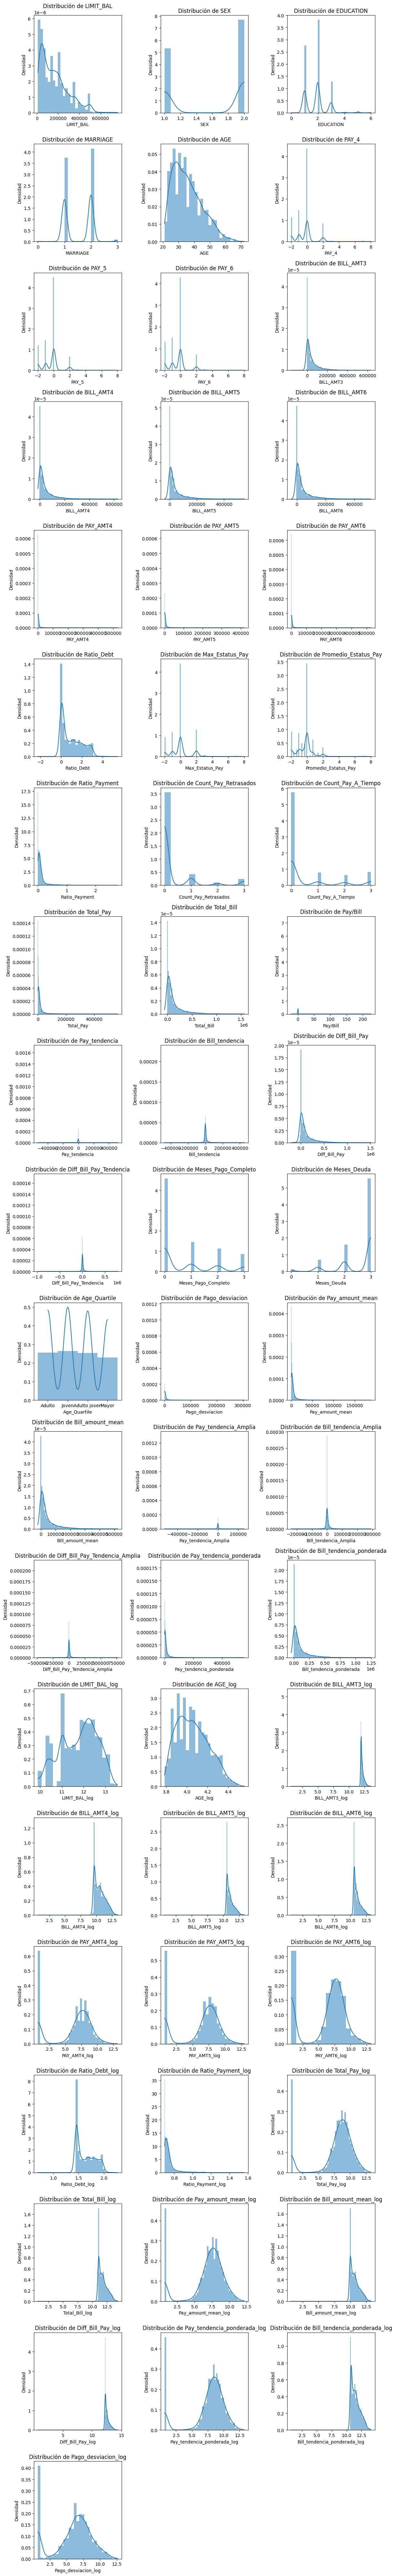

In [49]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

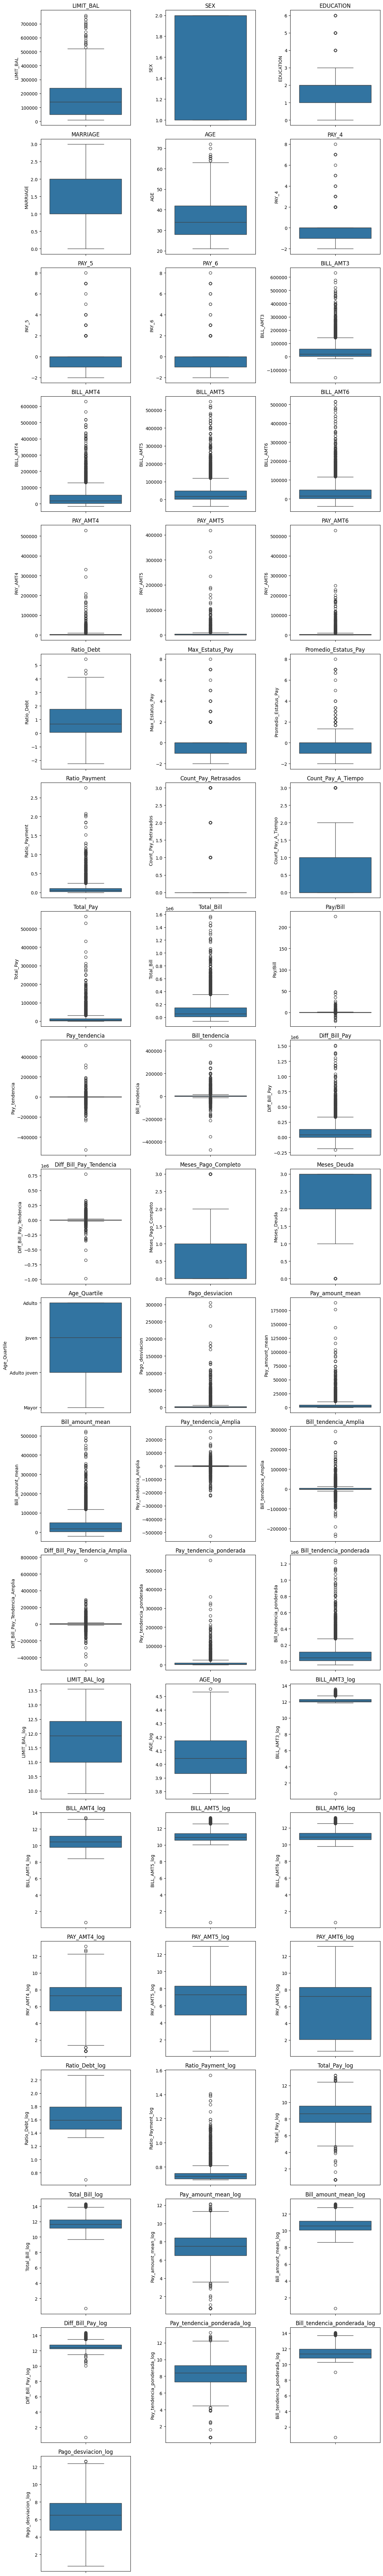

In [50]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i) 
    sns.boxplot(y=df[var])  
    plt.title(var)  
plt.tight_layout()  
plt.show()


In [51]:
df.isnull().sum().sum()

np.int64(0)

In [52]:
X_test.isnull().sum().sum()

np.int64(0)

In [53]:
df.describe([0.01,0.05, 0.25, 0.5, 0.75, 0.95 ,0.99])

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3.937000e+03,3937.000000,3937.000000,3937.000000,3.937000e+03,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3.937000e+03,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000
mean,168196.596393,1.591313,1.863602,1.538227,35.625603,-0.211836,-0.273305,-0.293879,46210.510033,42838.797054,39355.719583,37776.627889,4787.481077,4599.641859,5460.019812,0.989194,0.011938,-0.259673,0.105474,0.311913,0.562357,14847.142748,1.199711e+05,0.490787,-672.538735,5062.169164,1.051240e+05,5734.707899,0.782068,2.574295,4615.436820,4949.047583,39990.381509,-766.458344,3320.630429,4087.088773,11513.224359,9.502156e+04,11.782743,4.059248,12.180788,10.562047,11.061621,11.067015,6.175393,6.093585,6.045108,1.638932,0.741572,7.924539,11.801988,6.950827,10.703692,12.554161,7.707513,11.508083,5.989584
std,131866.868064,0.491654,0.798842,0.521513,9.258348,1.189739,1.149399,1.174226,68400.653771,64184.720262,60477.729395,59195.760724,16481.016035,15114.793759,18463.362505,0.999487,1.264995,1.078394,0.180665,0.768897,1.009727,31826.528381,1.792213e+05,4.104406,23618.543461,28692.760290,1.708596e+05,42754.140916,1.045341,0.723186,15184.334772,10608.842794,59740.435225,20455.744326,20313.243633,33345.748137,24976.648178,1.413845e+05,0.836432,0.152959,0.319436,0.855350,0.578524,0.567506,3.161737,3.215074,3.296330,0.183328,0.073315,2.859112,0.738701,2.550351,0.734682,0.448374,2.786954,0.768748,2.833350
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-157264.000000,-15000.000000,-37594.000000,-39046.000000,0.000000,0.000000,0.000000,-2.250000,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,-6.137900e+04,-20.416395,-528566.000000,-472227.000000,-2.078750e+05,-986124.000000,0.000000,0.000000,0.000000,0.000000,-20459.666667,-528516.000000,-237493.500000,-489057.500000,0.000000,-4.346250e+04,9.903588,3.784190,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147
1%,10000.000000,1.000000,1.000000,1.000000,22.000000,-2.000000,-2.000000,-2.000000,-347.200000,-284.800000,-229.040000,-437.440000,0.000000,0.000000,0.000000,-0.000266,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,-5.400000e+01,0.000000,-79460.000000,-56607.080000,-4.263352e+04,-80243.640000,0.000000,0.000000,0.000000,0.000000,-18.000000,-81950.400000,-47488.720000,-81702.400000,0.000000,-4.230000e+01,9.903588,3.806662,11.963484,9.596770,10.528542,10.561280,0.693147,0.693147,0.693147,1.446856,0.693147,0.693147,11.023975,0.693147,9.925428,12.015172,0.693147,10.678726,0.693147
5%,20000.000000,1.000000,1.000000,1.000000,24.00000

### Outiliers

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3937 entries, 1779 to 1922
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LIMIT_BAL                       3937 non-null   float64
 1   SEX                             3937 non-null   int64  
 2   EDUCATION                       3937 non-null   int64  
 3   MARRIAGE                        3937 non-null   int64  
 4   AGE                             3937 non-null   int64  
 5   PAY_4                           3937 non-null   int64  
 6   PAY_5                           3937 non-null   int64  
 7   PAY_6                           3937 non-null   int64  
 8   BILL_AMT3                       3937 non-null   float64
 9   BILL_AMT4                       3937 non-null   float64
 10  BILL_AMT5                       3937 non-null   float64
 11  BILL_AMT6                       3937 non-null   float64
 12  PAY_AMT4                        3937

In [55]:
lst_out_upper = ['BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','Pago_desviacion',
               'PAY_AMT4','PAY_AMT5','PAY_AMT6','Promedio_Estatus_Pay','Ratio_Payment','Total_Pay', 'Total_Bill',
                 'Pay/Bill','Pay_amount_mean','Bill_amount_mean','Diff_Bill_Pay','Ratio_Payment_log','Pay_tendencia_ponderada','Bill_tendencia_ponderada']
lst_out_both = ['Pay/Bill','Pay_tendencia','Bill_tendencia','Pay_tendencia_Amplia','Bill_tendencia_Amplia','Diff_Bill_Pay_Tendencia',
                'Diff_Bill_Pay_Tendencia_Amplia','BILL_AMT3_log','BILL_AMT4_log','BILL_AMT5_log','Pago_desviacion_log',
                'BILL_AMT6_log','PAY_AMT4_log','PAY_AMT5_log','Total_Pay_log','Diff_Bill_Pay_log','Pay_tendencia_ponderada_log']
lst_out_lower = ['Total_Bill_log','Bill_amount_mean_log','Bill_tendencia_ponderada_log']

In [56]:
for v in lst_out_upper: # Debido a la gran cantidad de outliers vistos en los boxplot, aplicamos winsorize parta no perder tantos datos
    df[v] = winsorize(df[v], limits = [0, 0.1])

for v in lst_out_both:
    df[v] = winsorize(df[v], limits = [0.05, 0.05])

for v in lst_out_lower:
    df[v] = winsorize(df[v], limits = [0.1, 0])


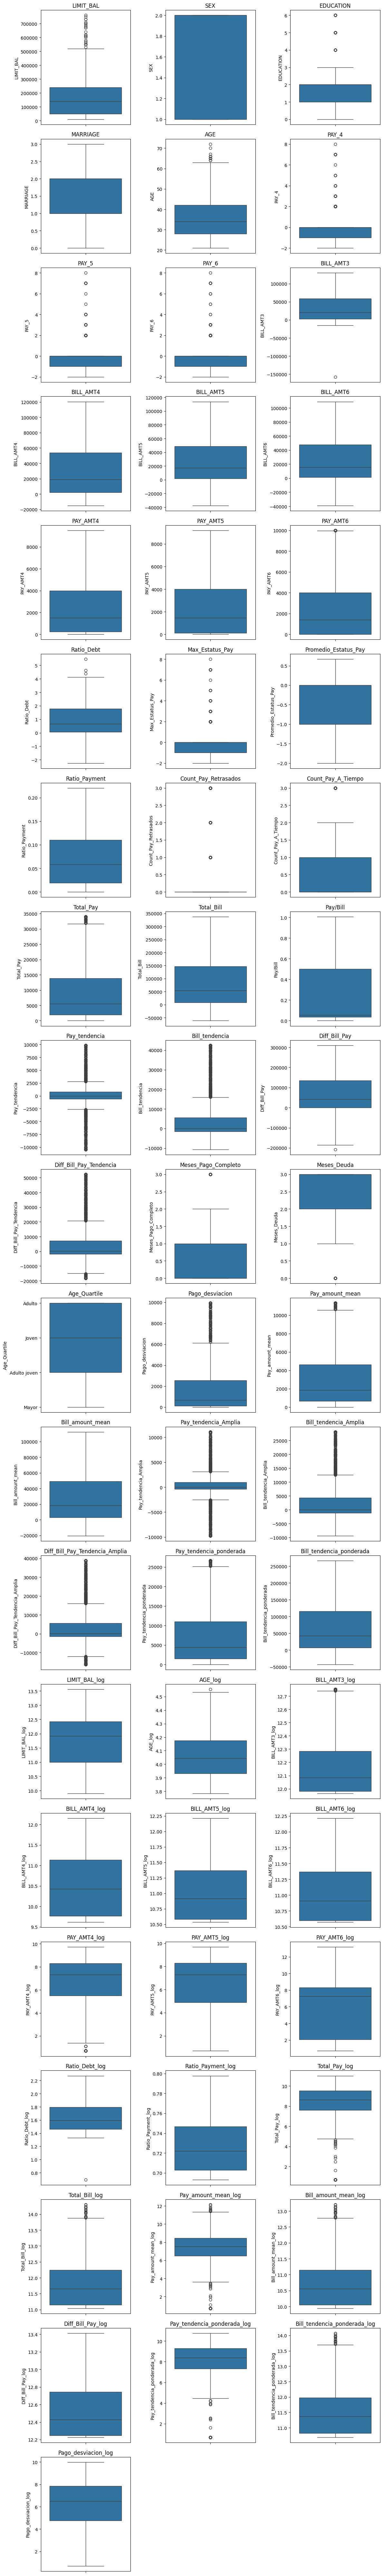

In [57]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.boxplot(y=df[var])  
    plt.title(var)  
plt.tight_layout()  
plt.show()

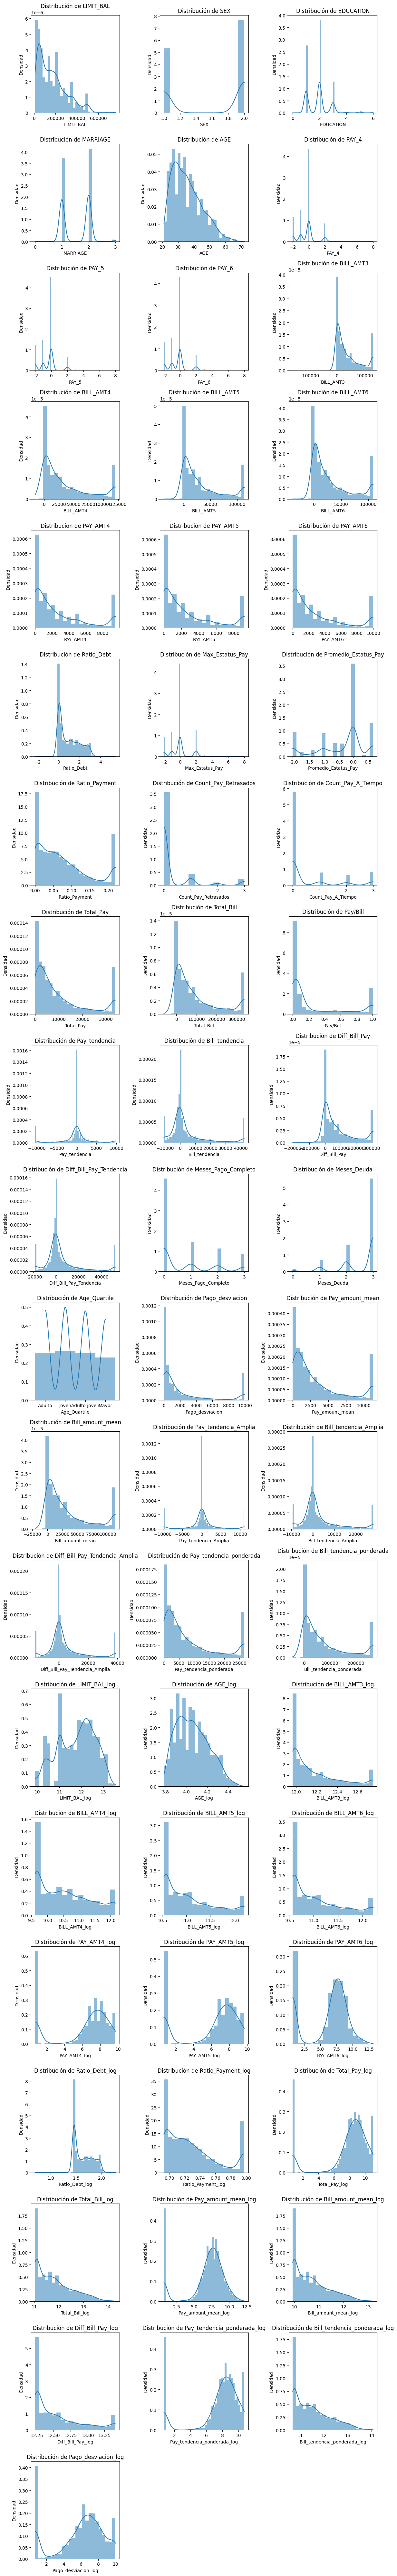

In [58]:
aux = df
list_column = aux.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    plt.plot(linewidth=2)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

### Codificacion

In [59]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,110000.0,1,2,1,39,0,0,0,34533.0,36819.0,32467.0,35806.0,3000.0,4000.0,3000.0,0.955382,0,0.000000,0.090909,0,0,10000.0,105092.0,0.095155,0.0,1013.0,95092.0,1013.0,0,3,Adulto,577.350269,3333.333333,35030.666667,500.0,-1163.0,-1663.0,7800.00,82652.85,11.695264,4.127134,12.164203,10.855551,11.157150,11.223295,8.007034,8.294550,8.007034,1.649693,0.737599,9.210540,12.022588,8.112328,10.924000,12.621386,8.962135,11.744968,6.361907
1070,130000.0,1,2,2,25,0,0,0,7559.0,5198.0,5198.0,5198.0,0.0,0.0,0.0,0.119954,0,0.000000,0.000000,0,0,0.0,15594.0,0.000000,0.0,0.0,15594.0,0.0,0,3,Joven,0.000000,0.000000,5198.000000,0.0,0.0,0.0,0.00,12215.30,11.849412,3.871201,12.012640,9.913438,10.664153,10.697520,0.693147,0.693147,0.693147,1.474752,0.693147,0.693147,11.251236,0.693147,10.152676,12.317037,0.693147,10.927373,0.693147
3385,50000.0,1,3,1,41,2,0,0,29261.0,28444.0,28878.0,27655.0,1100.0,1100.0,2000.0,1.699540,2,0.666667,0.084000,1,0,4200.0,84977.0,0.049425,-900.0,789.0,80777.0,1689.0,0,3,Adulto,519.615242,1400.000000,28325.666667,-900.0,1006.0,1906.0,3125.00,66695.50,11.002133,4.158883,12.136331,10.679274,11.104566,11.108005,7.004882,7.004882,7.601902,1.783314,0.734289,8.343316,11.893811,7.245655,10.795226,12.572984,8.047829,11.609689,6.256930
2705,70000.0,2,2,1,41,3,3,2,53896.0,54426.0,52956.0,54459.0,0.0,2500.0,2200.0,2.312014,3,0.666667,0.067143,3,0,4700.0,161841.0,0.029041,-2200.0,-33.0,157141.0,2167.0,0,3,Adulto,1365.039682,1566.666667,53947.000000,-950.0,-768.0,182.0,3195.00,126818.40,11.289807,4.158883,12.260381,11.148046,11.413680,11.445792,0.693147,7.824846,7.697121,1.881298,0.726167,8.455743,12.315922,7.357981,11.217328,12.807702,8.069968,12.045216,7.220403
4025,400000.0,2,1,2,31,-1,0,0,28082.0,20188.0,68992.0,27613.0,9500.0,9194.0,10000.0,0.291982,0,-0.333333,0.220660,0,1,33977.0,116793.0,1.006706,-10443.0,-7425.0,-71994.0,51225.0,2,1,Adulto joven,9926.895436,11325.666667,38931.000000,-9750.0,16977.0,38724.0,26612.45,88499.80,12.923917,3.988984,12.129990,10.468517,11.576726,11.107375,9.728658,9.680469,11.658860,1.513364,0.797804,11.013122,12.090516,11.049794,10.991926,12.226747,10.751259,11.790287,9.988908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,120000.0,1,2,2,25,2,2,0,54675.0,52206.0,10325.0,8992.0,0.0,500.0,1000.0,0.596025,2,0.666667,0.012500,2,0,1500.0,71523.0,0.020972,-1000.0,42351.0,70023.0,44214.0,0,3,Joven,500.000000,500.000000,23841.000000,-750.0,22273.5,23023.5,975.00,65344.95,11.775305,3.871201,12.264063,11.115548,10.777309,10.779789,0.693147,6.218600,6.909753,1.578159,0.699378,7.314553,11.797382,6.218600,10.698800,12.535017,6.884487,11.597353,6.218600
70,140000.0,2,1,2,27,0,0,0,29840.0,31349.0,35687.0,36983.0,5000.0,2000.0,5000.0,0.742993,0,0.000000,0.085714,0,0,12000.0,104019.0,0.115364,0.0,-5634.0,92019.0,-5634.0,0,3,Joven,1732.050808,4000.000000,34673.000000,-1500.0,-3465.0,-1965.0,9500.00,80304.05,11.918404,3.912023,12.139431,10.743998,11.202084,11.238896,8.517593,7.601902,8.517

In [60]:
X_test

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
3782,150000.0,2,1,1,54,-2,-2,-2,329.0,39919.0,263.0,263.0,264.0,264.0,790.0,0.269633,-2,-2.000000,0.008787,0,0,1318.0,40445.0,0.032587,-526.0,39656.0,39127.0,40182.0,2,1,Mayor,303.686242,439.333333,13481.666667,-526.0,19828.0,20354.0,936.0,40274.05,11.982942,4.343805,11.967784,10.913651,10.541624,10.579260,5.583496,5.583496,6.674561,1.508431,0.697531,7.185387,11.531021,6.089800,10.432448,12.417160,6.843750,11.335455,5.722559
4889,10000.0,2,2,1,37,0,2,0,8226.0,9834.0,9549.0,9774.0,0.0,508.0,425.0,2.915700,2,0.666667,0.093300,1,0,933.0,29157.0,0.031999,-425.0,60.0,28224.0,485.0,0,3,Adulto,272.512385,311.000000,9719.000000,-171.0,-82.5,88.5,636.0,22860.15,9.903588,4.094345,12.016678,10.120049,10.760983,10.795936,0.693147,6.234411,6.056784,1.969306,0.738742,6.840547,11.413525,5.746203,10.314957,12.372015,6.458338,11.102317,5.614996
1302,70000.0,2,1,1,23,-2,-2,-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-2,-2.000000,0.000000,0,0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,3,3,Joven,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,11.289807,3.828641,11.965694,9.615939,10.534653,10.572547,0.693147,0.693147,0.693147,1.446919,0.693147,0.693147,11.024856,0.693147,9.926308,12.244702,0.693147,10.679700,0.693147
313,10000.0,1,2,2,25,0,0,0,7308.0,5736.0,6236.0,-764.0,500.0,180.0,5000.0,1.120800,0,0.000000,0.568000,0,0,5680.0,11208.0,0.506781,-4500.0,6500.0,5528.0,11000.0,1,2,Joven,2695.205620,1893.333333,3736.000000,-4660.0,6750.0,11410.0,3635.0,9954.60,9.903588,3.871201,12.011116,9.939723,10.688119,10.552787,6.218600,5.204007,8.517593,1.680977,0.943127,8.645059,11.192569,7.547150,10.094011,12.270947,8.198914,10.885924,7.899972
5138,20000.0,1,2,1,34,0,0,0,19499.0,19780.0,780.0,0.0,0.0,0.0,0.0,1.028000,0,0.000000,0.000000,0,0,0.0,20560.0,0.000000,0.0,19780.0,20560.0,19780.0,1,3,Adulto joven,0.000000,0.000000,6853.333333,0.0,10280.0,10280.0,0.0,20365.00,10.309019,4.043051,12.082576,10.456855,10.555188,10.572547,0.693147,0.693147,0.693147,1.663547,0.693147,0.693147,11.313755,0.693147,10.215191,12.339016,0.693147,11.063971,0.693147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,20000.0,1,3,2,27,0,0,0,19872.0,20100.0,19704.0,18004.0,394.0,0.0,226.0,2.890400,0,0.000000,0.031000,0,0,620.0,57808.0,0.010725,168.0,2096.0,57188.0,1928.0,0,3,Joven,197.710226,206.666667,19269.333333,-29.0,1898.0,1927.0,529.6,45680.40,10.309019,3.912023,12.084684,10.466013,10.956056,10.951718,5.981414,0.693147,5.429346,1.965769,0.708528,6.432940,11.688466,5.340738,10.589887,12.487730,6.275891,11.398018,5.296867
2379,260000.0,2,1,1,52,2,-1,-1,150.0,150.0,2500.0,0.0,2500.0,0.0,0.0,0.010192,2,0.000000,0.009615,1,2,2500.0,2650.0,0.943396,2500.0,150.0,150.0,-2350.0,2,2,Mayor,1443.375673,833.333333,883.333333,1250.0,1325.0,75.0,2500.0,2025.00,12.506185,4.317488,11.966647,9.625888,10.599032,10.572547,7.824846,0.693147,0.693147,1.449314,0.697943,7.824846,11.067123,6.727831,9.968573,12.245423,7.824846,10.725237,7.276125
2271,50000.0,2,1,2,25,0,2,2,36989.0,38559.0,3995

In [61]:
df['Age_Quartile'].unique()

array(['Adulto', 'Joven', 'Adulto joven', 'Mayor'], dtype=object)

In [62]:
df = pd.get_dummies(df, columns = ['EDUCATION'],prefix='EDUCATION') # Codificamos las variables para el modelo
df = pd.get_dummies(df, columns = ['MARRIAGE'],prefix='MARRIAGE')
df = pd.get_dummies(df, columns = ['SEX'],prefix='SEX')
mapeo_Age = {'Joven':1, 'Adulto joven' :2, 'Adulto':3, 'Mayor':4}
df['Age_Quartile'] = df['Age_Quartile'].map(mapeo_Age)
X_test = pd.get_dummies(X_test, columns = ['EDUCATION'],prefix='EDUCATION') # Codificamos las variables para el modelo
X_test = pd.get_dummies(X_test, columns = ['MARRIAGE'],prefix='MARRIAGE')
X_test = pd.get_dummies(X_test, columns = ['SEX'],prefix='SEX')
X_test['Age_Quartile'] = X_test['Age_Quartile'].map(mapeo_Age)

In [63]:
df

,LIMIT_BAL,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
1779,110000.0,39,0,0,0,34533.0,36819.0,32467.0,35806.0,3000.0,4000.0,3000.0,0.955382,0,0.000000,0.090909,0,0,10000.0,105092.0,0.095155,0.0,1013.0,95092.0,1013.0,0,3,3,577.350269,3333.333333,35030.666667,500.0,-1163.0,-1663.0,7800.00,82652.85,11.695264,4.127134,12.164203,10.855551,11.157150,11.223295,8.007034,8.294550,8.007034,1.649693,0.737599,9.210540,12.022588,8.112328,10.924000,12.621386,8.962135,11.744968,6.361907,False,False,True,False,False,False,False,False,True,False,False,True,False
1070,130000.0,25,0,0,0,7559.0,5198.0,5198.0,5198.0,0.0,0.0,0.0,0.119954,0,0.000000,0.000000,0,0,0.0,15594.0,0.000000,0.0,0.0,15594.0,0.0,0,3,1,0.000000,0.000000,5198.000000,0.0,0.0,0.0,0.00,12215.30,11.849412,3.871201,12.012640,9.913438,10.664153,10.697520,0.693147,0.693147,0.693147,1.474752,0.693147,0.693147,11.251236,0.693147,10.152676,12.317037,0.693147,10.927373,0.693147,False,False,True,False,False,False,False,False,False,True,False,True,False
3385,50000.0,41,2,0,0,29261.0,28444.0,28878.0,27655.0,1100.0,1100.0,2000.0,1.699540,2,0.666667,0.084000,1,0,4200.0,84977.0,0.049425,-900.0,789.0,80777.0,1689.0,0,3,3,519.615242,1400.000000,28325.666667,-900.0,1006.0,1906.0,3125.00,66695.50,11.002133,4.158883,12.136331,10.679274,11.104566,11.108005,7.004882,7.004882,7.601902,1.783314,0.734289,8.343316,11.893811,7.245655,10.795226,12.572984,8.047829,11.609689,6.256930,False,False,False,True,False,False,False,False,True,False,False,True,False
2705,70000.0,41,3,3,2,53896.0,54426.0,52956.0,54459.0,0.0,2500.0,2200.0,2.312014,3,0.666667,0.067143,3,0,4700.0,161841.0,0.029041,-2200.0,-33.0,157141.0,2167.0,0,3,3,1365.039682,1566.666667,53947.000000,-950.0,-768.0,182.0,3195.00,126818.40,11.289807,4.158883,12.260381,11.148046,11.413680,11.445792,0.693147,7.824846,7.697121,1.881298,0.726167,8.455743,12.315922,7.357981,11.217328,12.807702,8.069968,12.045216,7.220403,False,False,True,False,False,False,False,False,True,False,False,False,True
4025,400000.0,31,-1,0,0,28082.0,20188.0,68992.0,27613.0,9500.0,9194.0,10000.0,0.291982,0,-0.333333,0.220660,0,1,33977.0,116793.0,1.006706,-10443.0,-7425.0,-71994.0,51225.0,2,1,2,9926.895436,11325.666667,38931.000000,-9750.0,16977.0,38724.0,26612.45,88499.80,12.923917,3.988984,12.129990,10.468517,11.576726,11.107375,9.728658,9.680469,11.658860,1.513364,0.797804,11.013122,12.090516,11.049794,10.991926,12.226747,10.751259,11.790287,9.988908,False,True,False,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,120000.0,25,2,2,0,54675.0,52206.0,10325.0,8992.0,0.0,500.0,1000.0,0.596025,2,0.666667,0.012500,2,0,1500.0,71523.0,0.020972,-1000.0,42351.0,70023.0,44214.0,0,3,1,500.000000,500.000000,23841.000000,-750.0,22273.5,23023.5,975.00,65344.95,11.775305,3.871201,12.264063,11.115548,10.777309,10.779

In [64]:
X_test = X_test.reindex(columns=df.columns, fill_value= False)

In [65]:
X_test

,LIMIT_BAL,AGE,PAY_4,PAY_5,PAY_6,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Max_Estatus_Pay,Promedio_Estatus_Pay,Ratio_Payment,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
3782,150000.0,54,-2,-2,-2,329.0,39919.0,263.0,263.0,264.0,264.0,790.0,0.269633,-2,-2.000000,0.008787,0,0,1318.0,40445.0,0.032587,-526.0,39656.0,39127.0,40182.0,2,1,4,303.686242,439.333333,13481.666667,-526.0,19828.0,20354.0,936.0,40274.05,11.982942,4.343805,11.967784,10.913651,10.541624,10.579260,5.583496,5.583496,6.674561,1.508431,0.697531,7.185387,11.531021,6.089800,10.432448,12.417160,6.843750,11.335455,5.722559,False,True,False,False,False,False,False,False,True,False,False,False,True
4889,10000.0,37,0,2,0,8226.0,9834.0,9549.0,9774.0,0.0,508.0,425.0,2.915700,2,0.666667,0.093300,1,0,933.0,29157.0,0.031999,-425.0,60.0,28224.0,485.0,0,3,3,272.512385,311.000000,9719.000000,-171.0,-82.5,88.5,636.0,22860.15,9.903588,4.094345,12.016678,10.120049,10.760983,10.795936,0.693147,6.234411,6.056784,1.969306,0.738742,6.840547,11.413525,5.746203,10.314957,12.372015,6.458338,11.102317,5.614996,False,False,True,False,False,False,False,False,True,False,False,False,True
1302,70000.0,23,-2,-2,-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-2,-2.000000,0.000000,0,0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,3,3,1,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,11.289807,3.828641,11.965694,9.615939,10.534653,10.572547,0.693147,0.693147,0.693147,1.446919,0.693147,0.693147,11.024856,0.693147,9.926308,12.244702,0.693147,10.679700,0.693147,False,True,False,False,False,False,False,False,True,False,False,False,True
313,10000.0,25,0,0,0,7308.0,5736.0,6236.0,-764.0,500.0,180.0,5000.0,1.120800,0,0.000000,0.568000,0,0,5680.0,11208.0,0.506781,-4500.0,6500.0,5528.0,11000.0,1,2,1,2695.205620,1893.333333,3736.000000,-4660.0,6750.0,11410.0,3635.0,9954.60,9.903588,3.871201,12.011116,9.939723,10.688119,10.552787,6.218600,5.204007,8.517593,1.680977,0.943127,8.645059,11.192569,7.547150,10.094011,12.270947,8.198914,10.885924,7.899972,False,False,True,False,False,False,False,False,False,True,False,True,False
5138,20000.0,34,0,0,0,19499.0,19780.0,780.0,0.0,0.0,0.0,0.0,1.028000,0,0.000000,0.000000,0,0,0.0,20560.0,0.000000,0.0,19780.0,20560.0,19780.0,1,3,2,0.000000,0.000000,6853.333333,0.0,10280.0,10280.0,0.0,20365.00,10.309019,4.043051,12.082576,10.456855,10.555188,10.572547,0.693147,0.693147,0.693147,1.663547,0.693147,0.693147,11.313755,0.693147,10.215191,12.339016,0.693147,11.063971,0.693147,False,False,True,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,20000.0,27,0,0,0,19872.0,20100.0,19704.0,18004.0,394.0,0.0,226.0,2.890400,0,0.000000,0.031000,0,0,620.0,57808.0,0.010725,168.0,2096.0,57188.0,1928.0,0,3,1,197.710226,206.666667,19269.333333,-29.0,1898.0,1927.0,529.6,45680.40,10.309019,3.912023,12.084684,10.466013,10.956056,10.951718,5.981414,0.693147,5.429346,1.965769,0.708528,6.432940,11.688466,5.340738,10.589887,12.487730,6.275891,11.398018,5

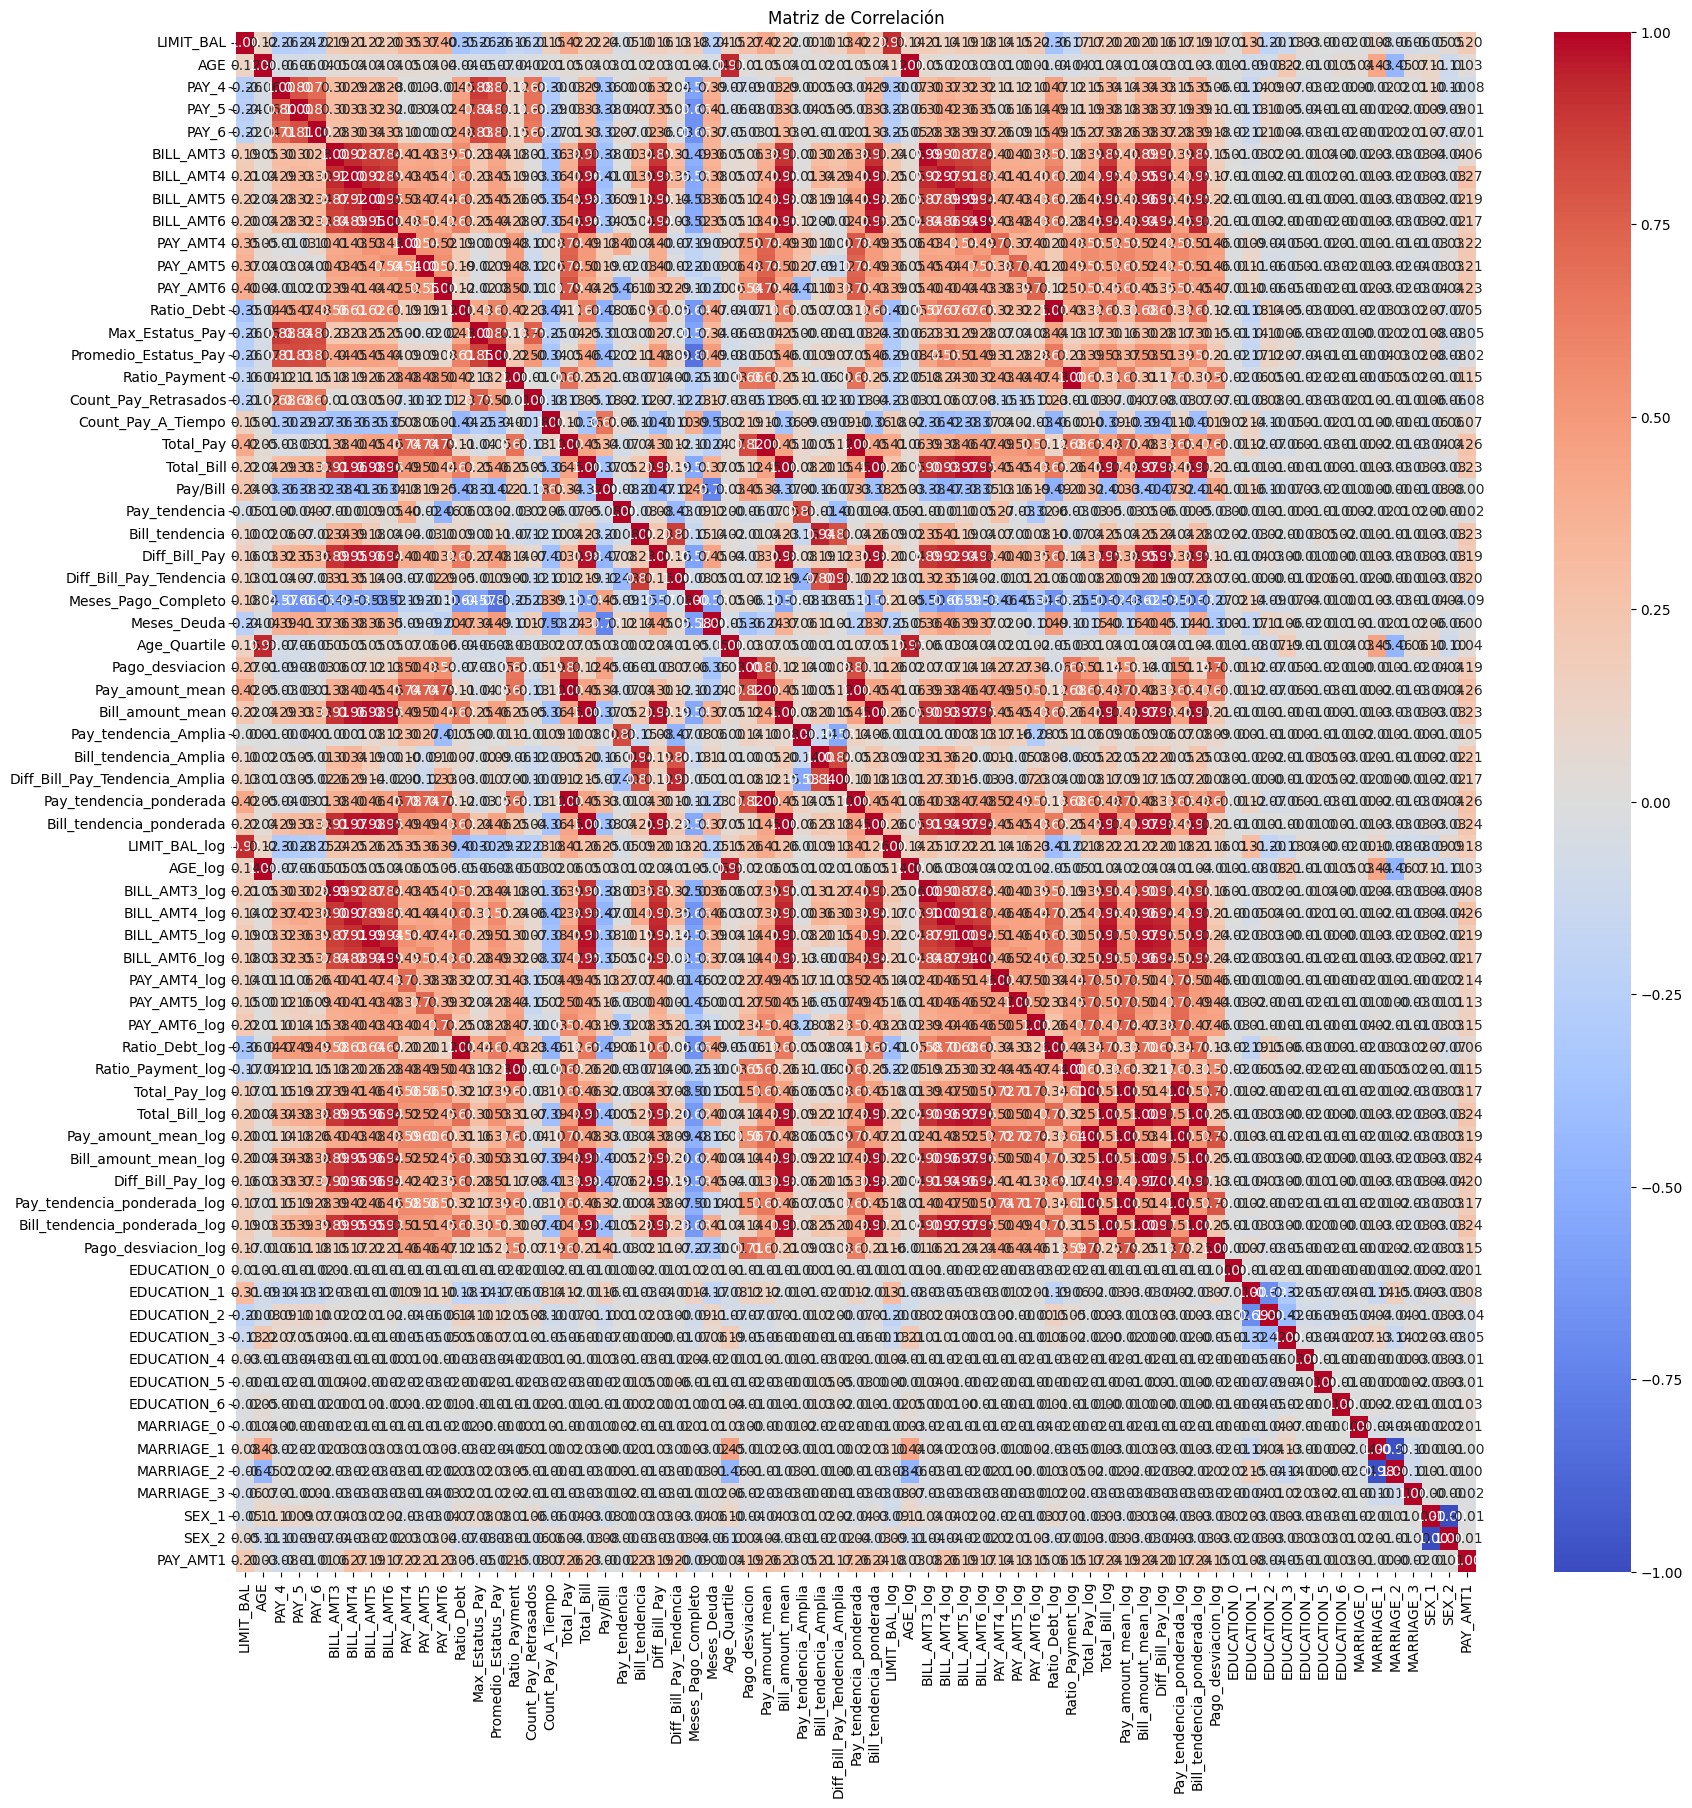

In [66]:
df_corr = df.copy()
df_corr['PAY_AMT1'] = y_train
correlation_matrix = df_corr.corr()
target_correlation = correlation_matrix["PAY_AMT1"].sort_values(ascending=False)
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3937 entries, 1779 to 1922
Data columns (total 68 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LIMIT_BAL                       3937 non-null   float64
 1   AGE                             3937 non-null   int64  
 2   PAY_4                           3937 non-null   int64  
 3   PAY_5                           3937 non-null   int64  
 4   PAY_6                           3937 non-null   int64  
 5   BILL_AMT3                       3937 non-null   float64
 6   BILL_AMT4                       3937 non-null   float64
 7   BILL_AMT5                       3937 non-null   float64
 8   BILL_AMT6                       3937 non-null   float64
 9   PAY_AMT4                        3937 non-null   float64
 10  PAY_AMT5                        3937 non-null   float64
 11  PAY_AMT6                        3937 non-null   float64
 12  Ratio_Debt                      3937

In [68]:
numeric_columns = df.select_dtypes(include = ['float64']).columns

In [69]:
numeric_columns

Index(['LIMIT_BAL', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Ratio_Debt',
       'Promedio_Estatus_Pay', 'Ratio_Payment', 'Total_Pay', 'Total_Bill',
       'Pay/Bill', 'Pay_tendencia', 'Bill_tendencia', 'Diff_Bill_Pay',
       'Diff_Bill_Pay_Tendencia', 'Pago_desviacion', 'Pay_amount_mean',
       'Bill_amount_mean', 'Pay_tendencia_Amplia', 'Bill_tendencia_Amplia',
       'Diff_Bill_Pay_Tendencia_Amplia', 'Pay_tendencia_ponderada',
       'Bill_tendencia_ponderada', 'LIMIT_BAL_log', 'AGE_log', 'BILL_AMT3_log',
       'BILL_AMT4_log', 'BILL_AMT5_log', 'BILL_AMT6_log', 'PAY_AMT4_log',
       'PAY_AMT5_log', 'PAY_AMT6_log', 'Ratio_Debt_log', 'Ratio_Payment_log',
       'Total_Pay_log', 'Total_Bill_log', 'Pay_amount_mean_log',
       'Bill_amount_mean_log', 'Diff_Bill_Pay_log',
       'Pay_tendencia_ponderada_log', 'Bill_tendencia_ponderada_log',
       'Pago_desviacion_log'],
      dtype='object')

In [70]:
len(numeric_columns)

45

In [71]:
numeric_columns

Index(['LIMIT_BAL', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Ratio_Debt',
       'Promedio_Estatus_Pay', 'Ratio_Payment', 'Total_Pay', 'Total_Bill',
       'Pay/Bill', 'Pay_tendencia', 'Bill_tendencia', 'Diff_Bill_Pay',
       'Diff_Bill_Pay_Tendencia', 'Pago_desviacion', 'Pay_amount_mean',
       'Bill_amount_mean', 'Pay_tendencia_Amplia', 'Bill_tendencia_Amplia',
       'Diff_Bill_Pay_Tendencia_Amplia', 'Pay_tendencia_ponderada',
       'Bill_tendencia_ponderada', 'LIMIT_BAL_log', 'AGE_log', 'BILL_AMT3_log',
       'BILL_AMT4_log', 'BILL_AMT5_log', 'BILL_AMT6_log', 'PAY_AMT4_log',
       'PAY_AMT5_log', 'PAY_AMT6_log', 'Ratio_Debt_log', 'Ratio_Payment_log',
       'Total_Pay_log', 'Total_Bill_log', 'Pay_amount_mean_log',
       'Bill_amount_mean_log', 'Diff_Bill_Pay_log',
       'Pay_tendencia_ponderada_log', 'Bill_tendencia_ponderada_log',
       'Pago_desviacion_log'],
      dtype='object')

In [72]:
categorical_columns = df.select_dtypes(exclude = ['float64']).columns

In [73]:
len(categorical_columns)

23

In [74]:
var_columns = list(categorical_columns) + list(numeric_columns)

In [75]:
var_columns

['AGE',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'Max_Estatus_Pay',
 'Count_Pay_Retrasados',
 'Count_Pay_A_Tiempo',
 'Meses_Pago_Completo',
 'Meses_Deuda',
 'Age_Quartile',
 'EDUCATION_0',
 'EDUCATION_1',
 'EDUCATION_2',
 'EDUCATION_3',
 'EDUCATION_4',
 'EDUCATION_5',
 'EDUCATION_6',
 'MARRIAGE_0',
 'MARRIAGE_1',
 'MARRIAGE_2',
 'MARRIAGE_3',
 'SEX_1',
 'SEX_2',
 'LIMIT_BAL',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'Ratio_Debt',
 'Promedio_Estatus_Pay',
 'Ratio_Payment',
 'Total_Pay',
 'Total_Bill',
 'Pay/Bill',
 'Pay_tendencia',
 'Bill_tendencia',
 'Diff_Bill_Pay',
 'Diff_Bill_Pay_Tendencia',
 'Pago_desviacion',
 'Pay_amount_mean',
 'Bill_amount_mean',
 'Pay_tendencia_Amplia',
 'Bill_tendencia_Amplia',
 'Diff_Bill_Pay_Tendencia_Amplia',
 'Pay_tendencia_ponderada',
 'Bill_tendencia_ponderada',
 'LIMIT_BAL_log',
 'AGE_log',
 'BILL_AMT3_log',
 'BILL_AMT4_log',
 'BILL_AMT5_log',
 'BILL_AMT6_log',
 'PAY_AMT4_log',
 'PAY_AMT5_log',
 'PAY_AMT6_lo

In [76]:
df[numeric_columns]

,LIMIT_BAL,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,110000.0,34533.0,36819.0,32467.0,35806.0,3000.0,4000.0,3000.0,0.955382,0.000000,0.090909,10000.0,105092.0,0.095155,0.0,1013.0,95092.0,1013.0,577.350269,3333.333333,35030.666667,500.0,-1163.0,-1663.0,7800.00,82652.85,11.695264,4.127134,12.164203,10.855551,11.157150,11.223295,8.007034,8.294550,8.007034,1.649693,0.737599,9.210540,12.022588,8.112328,10.924000,12.621386,8.962135,11.744968,6.361907
1070,130000.0,7559.0,5198.0,5198.0,5198.0,0.0,0.0,0.0,0.119954,0.000000,0.000000,0.0,15594.0,0.000000,0.0,0.0,15594.0,0.0,0.000000,0.000000,5198.000000,0.0,0.0,0.0,0.00,12215.30,11.849412,3.871201,12.012640,9.913438,10.664153,10.697520,0.693147,0.693147,0.693147,1.474752,0.693147,0.693147,11.251236,0.693147,10.152676,12.317037,0.693147,10.927373,0.693147
3385,50000.0,29261.0,28444.0,28878.0,27655.0,1100.0,1100.0,2000.0,1.699540,0.666667,0.084000,4200.0,84977.0,0.049425,-900.0,789.0,80777.0,1689.0,519.615242,1400.000000,28325.666667,-900.0,1006.0,1906.0,3125.00,66695.50,11.002133,4.158883,12.136331,10.679274,11.104566,11.108005,7.004882,7.004882,7.601902,1.783314,0.734289,8.343316,11.893811,7.245655,10.795226,12.572984,8.047829,11.609689,6.256930
2705,70000.0,53896.0,54426.0,52956.0,54459.0,0.0,2500.0,2200.0,2.312014,0.666667,0.067143,4700.0,161841.0,0.029041,-2200.0,-33.0,157141.0,2167.0,1365.039682,1566.666667,53947.000000,-950.0,-768.0,182.0,3195.00,126818.40,11.289807,4.158883,12.260381,11.148046,11.413680,11.445792,0.693147,7.824846,7.697121,1.881298,0.726167,8.455743,12.315922,7.357981,11.217328,12.807702,8.069968,12.045216,7.220403
4025,400000.0,28082.0,20188.0,68992.0,27613.0,9500.0,9194.0,10000.0,0.291982,-0.333333,0.220660,33977.0,116793.0,1.006706,-10443.0,-7425.0,-71994.0,51225.0,9926.895436,11325.666667,38931.000000,-9750.0,16977.0,38724.0,26612.45,88499.80,12.923917,3.988984,12.129990,10.468517,11.576726,11.107375,9.728658,9.680469,11.658860,1.513364,0.797804,11.013122,12.090516,11.049794,10.991926,12.226747,10.751259,11.790287,9.988908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,120000.0,54675.0,52206.0,10325.0,8992.0,0.0,500.0,1000.0,0.596025,0.666667,0.012500,1500.0,71523.0,0.020972,-1000.0,42351.0,70023.0,44214.0,500.000000,500.000000,23841.000000,-750.0,22273.5,23023.5,975.00,65344.95,11.775305,3.871201,12.264063,11.115548,10.777309,10.779789,0.693147,6.218600,6.909753,1.578159,0.699378,7.314553,11.797382,6.218600,10.698800,12.535017,6.884487,11.597353,6.218600
70,140000.0,29840.0,31349.0,35687.0,36983.0,5000.0,2000.0,5000.0,0.742993,0.000000,0.085714,12000.0,104019.0,0.115364,0.0,-5634.0,92019.0,-5634.0,1732.050808,4000.000000,34673.000000,-1500.0,-3465.0,-1965.0,9500.00,80304.05,11.918404,3.912023,12.139431,10.743998,11.202084,11.238896,8.517593,7.601902,8.517593,1.608036,0.735111,9.392829,12.016122,8.294550,10.917534,12.611191,9.159258,11.726169,7.458215
2878,160000.0,5958.0,55914.0,23285.0,29170.0,9500.0,9194.0,9976.0,0.677306,-1.000000,0.220660,33977.0,108369.0,0.413938,9800.0,26744.0,63511.0,13418.0,7275.075899,11325.666667,36123.000000,7465.0,10429.5,2964.5,26612.45,90879.75,12.043565,3.912023,12.002879,11.169251,11.016676,11.130464,9.728658,9.357207,9.208138,1.594792,0.79

In [77]:
sc = StandardScaler()
df[numeric_columns] = sc.fit_transform(df[numeric_columns])

In [78]:
df[numeric_columns].describe()

,LIMIT_BAL,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03,3.937000e+03
mean,-7.850802e-17,7.941041e-17,2.887651e-17,-2.346217e-17,3.248608e-17,-4.421716e-17,1.895021e-17,5.955781e-17,3.970521e-17,1.624304e-17,-1.804782e-17,-4.466836e-17,2.707173e-17,1.624304e-17,-3.609564e-18,1.443826e-17,4.511955e-17,-1.714543e-17,-1.506993e-16,-5.504586e-17,3.970521e-17,7.219129e-18,-2.707173e-18,-1.804782e-18,5.549705e-17,-1.010678e-16,4.304405e-16,1.386073e-15,-3.696194e-15,1.160475e-15,4.894569e-15,4.241238e-16,9.475106e-18,-1.206948e-16,1.037750e-17,-6.461120e-16,-4.705969e-16,1.863438e-16,-7.399607e-17,3.564445e-17,-2.580838e-15,5.071438e-16,-2.887651e-16,-1.721762e-15,3.068130e-17
std,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00,1.000127e+00
min,-1.199821e+00,-4.523963e+00,-1.254075e+00,-1.853817e+00,-1.911959e+00,-8.771725e-01,-8.811979e-01,-8.461332e-01,-3.241266e+00,-2.009109e+00,-1.098135e+00,-9.175447e-01,-1.435309e+00,-7.513172e-01,-2.629682e+00,-1.204963e+00,-2.760508e+00,-1.478174e+00,-6.912195e-01,-9.175447e-01,-1.435309e+00,-2.492301e+00,-1.423607e+00,-1.668616e+00,-9.183381e-01,-1.380696e+00,-2.246917e+00,-1.798486e+00,-8.985044e-01,-1.162417e+00,-9.973362e-01,-9.564846e-01,-1.751122e+00,-1.695474e+00,-1.623818e+00,-5.159622e+00,-1.117870e+00,-2.551885e+00,-1.078564e+00,-2.453966e+00,-1.078553e+00,-9.138330e-01,-2.539797e+00,-1.100962e+00,-1.896848e+00
25%,-8.964466e-01,-8.215551e-01,-8.178559e-01,-8.070250e-01,-8.069588e-01,-7.968169e-01,-8.368187e-01,-8.442582e-01,-9.345914e-01,-7.733217e-01,-8.188638e-01,-7.336209e-01,-8.057720e-01,-6.574604e-01,-1.446447e-01,-4.759196e-01,-7.869138e-01,-4.406088e-01,-6.544306e-01,-7.336209e-01,-8.057720e-01,-1.766010e-01,-4.733105e-01,-4.224926e-01,-7.363355e-01,-8.070757e-01,-9.333798e-01,-8.331609e-01,-8.284106e-01,-9.778502e-01,-9.084562e-01,-9.016218e-01,-2.003572e-01,-3.657171e-01,-1.203208e+00,-9.771041e-01,-8.253831e-01,-1.076413e-01,-9.122880e-01,-1.786498e-01,-9.122831e-01,-8.531897e-01,-1.243843e-01,-9.196511e-01,-4.279822e-01
50%,-2.138534e-01,-4.189579e-01,-4.038239e-01,-3.904886e-01,-4.082482e-01,-3.871995e-01,-3.883196e-01,-4.086215e-01,-3.199219e-01,4.624654e-01,-2.491018e-01,-4.007005e-01,-3.919480e-01,-6.029198e-01,6.835795e-03,-3.549162e-01,-3.97633

In [79]:
X_test[numeric_columns] = sc.transform(X_test[numeric_columns])

In [80]:
X_test[numeric_columns].describe()

,LIMIT_BAL,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,-0.014000,0.178366,0.205678,0.208894,0.212351,0.561364,0.591810,0.805457,0.024296,0.157667,0.391151,0.389441,0.210580,0.719106,-0.215593,0.050199,0.220448,0.044037,0.629607,0.389441,0.210580,-0.295957,0.063023,0.065926,0.369835,0.209553,0.007787,-0.016854,0.032669,0.014284,0.040167,0.032833,0.012991,0.012207,0.024424,0.019181,0.317813,0.022328,-0.004366,0.010388,-0.003455,-0.017621,0.021137,0.001157,-0.005046
std,0.960987,1.547733,1.606000,1.552174,1.546797,4.059280,4.239627,5.826901,1.039346,1.392315,2.660820,2.768227,1.574447,10.039268,5.198289,2.060856,1.611554,2.239581,4.100010,2.768227,1.574447,4.684238,2.177020,2.405028,2.653831,1.578825,0.972203,0.988067,1.128328,1.062328,1.084075,1.194660,1.013424,1.008392,0.976190,1.030484,2.263128,0.982796,1.093999,0.970106,1.080804,1.693444,0.983461,1.021419,1.015591
min,-1.199821,-1.291372,-1.066325,-1.083661,-2.871138,-0.877173,-0.881198,-0.846133,-1.335626,-2.009109,-1.098135,-0.917545,-1.442740,-212.055181,-101.448974,-12.460982,-4.578785,-20.595090,-0.691219,-0.917545,-1.442740,-99.501386,-16.767349,-19.388340,-0.918338,-1.274510,-2.246917,-1.798486,-1.413613,-2.026142,-1.501001,-21.816836,-1.751122,-1.695474,-1.623818,-1.510171,-1.117870,-2.551885,-16.521690,-2.453966,-14.984780,-35.159242,-2.539797,-3.179906,-1.896848
25%,-0.820603,-0.836750,-0.828542,-0.810981,-0.810138,-0.788242,-0.822026,-0.789725,-0.944232,-0.773322,-0.811408,-0.731763,-0.815782,-0.658113,-0.131643,-0.466174,-0.790508,-0.441033,-0.654809,-0.731763,-0.815782,-0.176539,-0.466956,-0.409061,-0.730690,-0.821139,-0.749067,-0.833161,-0.846146,-1.008693,-0.915766,-0.907306,-0.168038,-0.275979,-0.254394,-0.989326,-0.817612,-0.104084,-0.934717,-0.174720,-0.934711,-0.858295,-0.113293,-0.952915,-0.431649
50%,-0.213853,-0.437963,-0.408788,-0.382710,-0.368476,-0.387199,-0.410509,-0.377371,-0.323458,0.462465,-0.254563,-0.389739,-0.394069,-0.608216,0.006836,-0.354916,-0.398201,-0.323894,-0.481866,-0.389739,-0.394069,-0.074689,-0.337488,-0.282792,-0.394213,-0.399746,0.162211,-0.105906,-0.403271,-0.155174,-0.251428,-0.242259,0.379094,0.376792,0.385157,-0.253392,-0.242768,0.265635,-0.208169,0.233987,-0.208178,-0.349650,0.259828,-0.200626,0.193999
75%,0.544584,0.485809,0.498291,0.473743,0.502310,0.446980,0.463627,0.403900,0.858575,0.462465,0.428815,0.382926,0.502129,0.658442,0.211776,-0.003800,0.553257,0.066135,0.109466,0.382926,0.502129,0.157463,0.069402,0.133608,0.386282,0.486356,0.773001,0.651466,0.475722,0.751479,0.634457,0.640378,0.698667,0.708511,0.682495,0.921422,0.448270,0.585057,0.660759,0.587367,0.660751,0.598285,0.591257,0.661853,0.676956
max,3.502488,11.111339,14.586089,10.472908,10.387215,59.865444,81.489323,125.251013,4.910580,9.112975,31.449440,37.032325,10.160752,150.223013,

In [81]:

X_test.isnull().sum().sum()

np.int64(0)

In [82]:
X_test.isnull().sum().sum()

np.int64(0)

In [83]:
df[categorical_columns]

,AGE,PAY_4,PAY_5,PAY_6,Max_Estatus_Pay,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2
1779,39,0,0,0,0,0,0,0,3,3,False,False,True,False,False,False,False,False,True,False,False,True,False
1070,25,0,0,0,0,0,0,0,3,1,False,False,True,False,False,False,False,False,False,True,False,True,False
3385,41,2,0,0,2,1,0,0,3,3,False,False,False,True,False,False,False,False,True,False,False,True,False
2705,41,3,3,2,3,3,0,0,3,3,False,False,True,False,False,False,False,False,True,False,False,False,True
4025,31,-1,0,0,0,0,1,2,1,2,False,True,False,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,25,2,2,0,2,2,0,0,3,1,False,False,True,False,False,False,False,False,False,True,False,True,False
70,27,0,0,0,0,0,0,0,3,1,False,True,False,False,False,False,False,False,False,True,False,False,True
2878,27,-1,-1,-1,-1,0,3,0,3,1,False,True,False,False,False,False,False,False,False,True,False,True,False
1950,49,0,0,0,0,0,0,0,3,4,False,False,True,False,False,False,False,False,True,False,False,False,True


In [84]:
df[var_columns]

,AGE,PAY_4,PAY_5,PAY_6,Max_Estatus_Pay,Count_Pay_Retrasados,Count_Pay_A_Tiempo,Meses_Pago_Completo,Meses_Deuda,Age_Quartile,EDUCATION_0,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_0,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,SEX_1,SEX_2,LIMIT_BAL,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6,Ratio_Debt,Promedio_Estatus_Pay,Ratio_Payment,Total_Pay,Total_Bill,Pay/Bill,Pay_tendencia,Bill_tendencia,Diff_Bill_Pay,Diff_Bill_Pay_Tendencia,Pago_desviacion,Pay_amount_mean,Bill_amount_mean,Pay_tendencia_Amplia,Bill_tendencia_Amplia,Diff_Bill_Pay_Tendencia_Amplia,Pay_tendencia_ponderada,Bill_tendencia_ponderada,LIMIT_BAL_log,AGE_log,BILL_AMT3_log,BILL_AMT4_log,BILL_AMT5_log,BILL_AMT6_log,PAY_AMT4_log,PAY_AMT5_log,PAY_AMT6_log,Ratio_Debt_log,Ratio_Payment_log,Total_Pay_log,Total_Bill_log,Pay_amount_mean_log,Bill_amount_mean_log,Diff_Bill_Pay_log,Pay_tendencia_ponderada_log,Bill_tendencia_ponderada_log,Pago_desviacion_log
1779,39,0,0,0,0,0,0,0,3,3,False,False,True,False,False,False,False,False,True,False,False,True,False,-0.441384,-0.081356,0.045030,0.009242,0.148257,0.102774,0.463627,0.091392,-0.033834,0.462465,0.225034,0.011363,0.064249,-0.492064,0.006836,-0.274327,0.105288,-0.267388,-0.507275,0.011363,0.064249,0.049291,-0.471866,-0.438406,0.006797,0.056442,-0.104599,0.443875,-0.042422,0.379286,0.204646,0.327485,0.601877,0.708511,0.595261,0.058708,0.243831,0.465863,0.302252,0.455486,0.302243,0.191494,0.466325,0.311140,0.147486
1070,25,0,0,0,0,0,0,0,3,1,False,False,True,False,False,False,False,False,False,True,False,True,False,-0.289697,-0.706157,-0.747710,-0.715894,-0.694194,-0.877173,-0.881198,-0.846133,-0.869796,0.462465,-1.098135,-0.917545,-0.741942,-0.751317,0.006836,-0.354916,-0.646692,-0.330988,-0.691219,-0.917545,-0.741942,-0.074689,-0.337488,-0.299124,-0.918338,-0.746224,0.079717,-1.229558,-0.696049,-0.792418,-0.747284,-0.709904,-1.751122,-1.695474,-1.623818,-0.895661,-1.117870,-2.551885,-0.777148,-2.453966,-0.777147,-0.660945,-2.539797,-0.784537,-1.896848
3385,41,2,0,0,2,1,0,0,3,3,False,False,False,True,False,False,False,False,True,False,False,True,False,-0.896447,-0.203472,-0.164931,-0.086197,-0.076090,-0.517859,-0.511371,-0.221116,0.710801,1.286323,0.124473,-0.527403,-0.116945,-0.616656,-0.220385,-0.292147,-0.030119,-0.224946,-0.525670,-0.527403,-0.116945,-0.297854,-0.221250,-0.139490,-0.547691,-0.125399,-0.933380,0.651466,-0.162622,0.160051,0.103112,0.100011,0.279468,0.300647,0.472341,0.787661,0.142441,0.158602,0.122046,0.115617,0.122036,0.055927,0.133936,0.129850,0.109628
2705,41,3,3,2,3,3,0,0,3,3,False,False,True,False,False,False,False,False,True,False,False,False,True,-0.744759,0.367150,0.486439,0.554084,0.661659,-0.877173,-0.040682,-0.158615,1.323667,1.286323,-0.120880,-0.480958,0.575440,-0.672194,-0.548593,-0.357542,0.692216,-0.194936,-0.256317,-0.480958,0.575440,-0.310252,-0.426226,-0.283881,-0.539388,0.559727,-0.589407,0.651466,0.372349,0.743061,0.699980,0.766486,-1.751122,0.559965,0.501231,1.322200,-0.106354,0.198436,0.712732,0.159666,0.712725,0.713339,0.141985,0.713509,0.457087
4025,31,-1,0,0,0,0,1,2,1,2,False,True,False,False,False,False,False,False,False,True,False,False,True,1.758083,-0.230781,-0.371910,0.980513,-0.077246,2.225990,2.209882,2.278951,-0.697657,0.050536,2.113540,2.238605,0.169651,1.991502,-2.629682,-0.945613,-1.475196,2.885112,2.471495,2.238605,0.169651,-2.492301,1.624112,2.944138,2.238088,0.123071,1.364509,-0.459428,-0.189967,-0.102067,1.014808,0.098768,1.155752,1.146816,1.703247,-0.685023,2.088120,1.104526,0.397307,1.607421,0.397298,-0.913833,1.116745,0.371872,1.455498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,25,2,2,0,2,2,0,0,3,1,False,False,True,False,False,False,False,False,False,True,False,True,False,-0.365541,0

## Entrenamiento

In [85]:
model_Regression = LinearRegression() 

In [86]:
y_train

1779     3000.0
1070     2200.0
3385        0.0
2705     2000.0
4025    20214.0
         ...   
1993      500.0
70       2000.0
2878    56116.0
1950     2000.0
1922        0.0
Name: PAY_AMT3, Length: 3937, dtype: float64

In [87]:
model_Regression.fit(df[var_columns],y_train)

LinearRegression()

In [88]:
model_RandFor = RandomForestRegressor()

In [89]:
model_RandFor.fit(df[var_columns],y_train)

RandomForestRegressor()

In [90]:
cv_scores = cross_val_score(model_Regression,df[var_columns],y_train, cv=5, scoring='r2')

In [91]:
print(cv_scores)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))

[0.44526057 0.28693327 0.45431893 0.08782577 0.35166505]
r2: 0.33 (+/- 0.27)


In [92]:
y_pred = model_Regression.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"r2 de Regresion lineal con conunto de prueba: {r2}")

r2 de Regresion lineal con conunto de prueba: -24863.093360488627


In [93]:
cv_scores_RandFor = cross_val_score(model_RandFor, df[var_columns],y_train, cv=5, scoring='r2')

In [94]:
print(cv_scores_RandFor)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_RandFor.mean(), cv_scores_RandFor.std() * 2))

[0.56727035 0.71561481 0.79021963 0.56111921 0.71474754]
r2: 0.67 (+/- 0.18)


In [95]:
y_pred = model_RandFor.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"r2 de Regresion lineal con conunto de prueba: {r2}")

r2 de Regresion lineal con conunto de prueba: 0.5496632063652425


In [96]:
xgb_r = XGBRegressor(enable_categorical=True, tree_method='hist')

In [97]:
xgb_r.fit(df[var_columns],y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [98]:
cv_scores_xgb_r = cross_val_score(xgb_r,df[var_columns],y_train, cv=5, scoring = 'r2')

In [99]:
print(cv_scores_xgb_r)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_xgb_r.mean(), cv_scores_xgb_r.std() * 2))

[0.53367385 0.77232585 0.8617438  0.81453648 0.69003629]
r2: 0.73 (+/- 0.23)


In [100]:
y_pred = xgb_r.predict(X_test[var_columns])
r2 = r2_score(y_test, y_pred)
print(f"R2 XGB: {r2}")

R2 XGB: 0.6927608708081943


### Modelo con SelectKbest

In [181]:
selector = SelectKBest(score_func = f_regression, k = 45)

X_train_selected = selector.fit_transform(df[var_columns],y_train)
X_test_selected = selector.transform(X_test[var_columns])

In [182]:
model_k_best = LinearRegression()# Marcaba error de que el modelo no convergia 

In [183]:
model_k_best.fit(X_train_selected, y_train)

LinearRegression()

In [184]:
cv_scores_kbest = cross_val_score(model_k_best, X_train_selected, y_train, cv=5, scoring='r2')

In [185]:
print(cv_scores_kbest)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_kbest.mean(), cv_scores_kbest.std() * 2))

[0.45027227 0.28535717 0.45911266 0.07623336 0.34718633]
r2: 0.32 (+/- 0.28)


In [186]:
y_pred = model_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 SelectKbeast con conjunto de prueba: {r2}")

R2 SelectKbeast con conjunto de prueba: -1695.7931039738473


In [187]:
model_RF_k_best = RandomForestRegressor()

In [188]:
model_RF_k_best.fit(X_train_selected,y_train)

RandomForestRegressor()

In [189]:
cv_scores_RF_k_best = cross_val_score(model_RF_k_best, X_train_selected, y_train, cv=5, scoring = 'r2')

In [190]:
print(cv_scores_RF_k_best)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_RF_k_best.mean(), cv_scores_RF_k_best.std() * 2))

[0.55924104 0.74406732 0.78712579 0.55326373 0.74994436]
r2: 0.68 (+/- 0.20)


In [191]:
y_pred = model_RF_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 Random Forest SelectKbeast con conjunto de prueba: {r2}")

R2 Random Forest SelectKbeast con conjunto de prueba: 0.5723271326761994


In [192]:
model_XGBr_k_best = XGBRegressor()

In [193]:
model_XGBr_k_best.fit(X_train_selected, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [194]:
cv_scores_XGBr_kbest = cross_val_score(model_XGBr_k_best, X_train_selected, y_train, cv=5, scoring='r2')

In [195]:
print(cv_scores_XGBr_kbest)
print("r2: %0.2f (+/- %0.2f)" % (cv_scores_XGBr_kbest.mean(), cv_scores_XGBr_kbest.std() * 2))

[0.60469976 0.78845809 0.79667382 0.82470165 0.81844166]
r2: 0.77 (+/- 0.16)


In [196]:
y_pred = model_XGBr_k_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
print(f"R2 SelectKbeast con conjunto de prueba: {r2}")

R2 SelectKbeast con conjunto de prueba: 0.6966510338922134
